# Исследовательский анализ данных сервиса Яндекс Афиша

- Автор: Омурбеков Марс
- Дата: 13.05.2026

### Цель и задачи

**Цель:**  
Провести исследовательский анализ данных сервиса Яндекс Афиша за период с 1 июня по 31 октября 2024 года, чтобы выявить особенности изменения пользовательского спроса осенью, изучить популярность мероприятий, регионов и партнёров, а также проверить гипотезы о различиях в активности пользователей мобильных и стационарных устройств.

**Задачи:**
1. Загрузить данные о заказах, мероприятиях и курсе тенге к рублю и познакомиться с их содержимым.
2. Провести предобработку данных:
   - проверить корректность выгрузки данных;
   - проверить и при необходимости скорректировать типы данных;
   - обработать пропущенные значения;
   - изучить категориальные значения и при необходимости нормализовать их;
   - проверить количественные признаки и обработать выбросы;
   - выявить явные и неявные дубликаты;
   - привести выручку к единой валюте;
   - создать дополнительные аналитические признаки.
3. Провести исследовательский анализ данных:
   - изучить динамику количества заказов по месяцам;
   - сравнить летний и осенний периоды по структуре заказов;
   - проанализировать распределение заказов по типам мероприятий, устройствам и возрастным рейтингам;
   - изучить изменение средней стоимости одного билета по типам мероприятий;
   - проанализировать осеннюю активность пользователей по дням;
   - изучить недельную цикличность пользовательской активности;
   - определить регионы и билетных партнёров, которые вносят наибольший вклад в количество мероприятий, заказов и выручку.
4. Провести статистический анализ данных:
   - проверить гипотезу о том, что среднее количество заказов на пользователя мобильного устройства выше, чем у пользователей стационарных устройств;
   - проверить гипотезу о том, что среднее время между заказами у пользователей мобильных устройств выше, чем у пользователей стационарных устройств.
5. Сформулировать итоговые выводы и подготовить рекомендации для продуктовой команды.

### Описание данных

В распоряжении имеются данные о бронировании билетов на сервисе Яндекс Афиша за период с 1 июня по 31 октября 2024 года.

---

#### Файл `final_tickets_orders_df.csv`

Содержит информацию обо всех заказах билетов, совершённых с мобильных и стационарных устройств.

**Столбцы:**

- `order_id` — уникальный идентификатор заказа;
- `user_id` — уникальный идентификатор пользователя;
- `created_dt_msk` — дата создания заказа, московское время;
- `created_ts_msk` — дата и время создания заказа, московское время;
- `event_id` — идентификатор мероприятия из таблицы событий;
- `cinema_circuit` — сеть кинотеатров; если не применимо, указано значение `'нет'`;
- `age_limit` — возрастное ограничение мероприятия;
- `currency_code` — валюта оплаты, например `rub` для российских рублей;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ, например `mobile` или `desktop`;
- `revenue` — выручка от заказа;
- `service_name` — название билетного оператора;
- `tickets_count` — количество купленных билетов;
- `total` — общая сумма заказа;
- `days_since_prev` — количество дней с предыдущей покупки пользователя.  
  Если предыдущей покупки не было, значение отсутствует.

---

#### Файл `final_tickets_events_df.csv`

Содержит информацию о событиях, включая город, регион и площадку проведения мероприятия. Из данных исключены фильмы.

**Столбцы:**

- `event_id` — уникальный идентификатор мероприятия;
- `event_name` — название мероприятия;
- `event_type_description` — описание типа мероприятия;
- `event_type_main` — основной тип мероприятия;
- `organizers` — организаторы мероприятия;
- `region_name` — название региона;
- `city_name` — название города;
- `venue_id` — уникальный идентификатор площадки;
- `venue_name` — название площадки;
- `venue_address` — адрес площадки.

---

#### Файл `final_tickets_tenge_df.csv`

Содержит информацию о курсе казахстанского тенге к российскому рублю за 2024 год.

Значения курса представлены в рублях за 100 тенге.

**Столбцы:**

- `nominal` — номинал, 100 тенге;
- `data` — дата;
- `curs` — курс тенге к рублю;
- `cdx` — обозначение валюты, `kzt`.

Данные о курсе используются для перевода выручки из тенге в российские рубли.

### Содержимое проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных и подготовка к исследованию.
3. Исследовательский анализ данных:
   - анализ распределения заказов по сегментам и их сезонные изменения;
   - анализ осенней активности пользователей;
   - анализ популярных событий, регионов и партнёров.
4. Статистический анализ данных.
5. Итоговые выводы и рекомендации.

---

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

## 1. Загрузка данных и знакомство с ними

In [2]:
final_tickets_orders_df = pd.read_csv("https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv")
final_tickets_events_df = pd.read_csv("https://code.s3.yandex.net/datasets/final_tickets_events_df.csv")
final_tickets_tenge_df = pd.read_csv("https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv") 

In [3]:
display(final_tickets_orders_df.head())
print(60 * '-')
final_tickets_orders_df.info()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  str    
 2   created_dt_msk         290849 non-null  str    
 3   created_ts_msk         290849 non-null  str    
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  str    
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  str    
 8   device_type_canonical  290849 non-null  str    
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  str    
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null 

#### Вывод
Таблица заказов содержит 290 849 строк и 14 столбцов. В данных представлены идентификаторы заказов, пользователей и мероприятий, даты создания заказов, информация об устройстве, валюте, выручке, количестве билетов и времени с предыдущей покупки.

На этапе первичного знакомства выявлено, что столбцы `created_dt_msk` и `created_ts_msk` имеют тип `object`, поэтому на этапе предобработки их потребуется привести к типу даты и даты-времени. Пропуски обнаружены только в столбце `days_since_prev`, что ожидаемо для первых покупок пользователей.

In [4]:
display(final_tickets_events_df.head())
print(60 * '-')
final_tickets_events_df.info()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   event_id                22427 non-null  int64
 1   event_name              22427 non-null  str  
 2   event_type_description  22427 non-null  str  
 3   event_type_main         22427 non-null  str  
 4   organizers              22427 non-null  str  
 5   region_name             22427 non-null  str  
 6   city_name               22427 non-null  str  
 7   city_id                 22427 non-null  int64
 8   venue_id                22427 non-null  int64
 9   venue_name              22427 non-null  str  
 10  venue_address           22427 non-null  str  
dtypes: int64(3), str(8)
memory usage: 6.8 MB


#### Вывод
Таблица мероприятий содержит 22 427 строк и 11 столбцов. В ней представлены идентификаторы мероприятий, названия событий, типы мероприятий, организаторы, регионы, города и площадки проведения.

Пропуски на этапе первичного знакомства не обнаружены. Типы данных в целом соответствуют содержимому столбцов: идентификаторы представлены числовыми типами, а категориальные и текстовые признаки — типом `object`. Таблица будет использоваться для обогащения данных о заказах через ключ `event_id`.

In [5]:
display(final_tickets_tenge_df.head())
print(40 * '-')
final_tickets_tenge_df.info()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    str    
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 15.8 KB


#### Вывод
Таблица курса тенге содержит 357 строк и 4 столбца. В данных представлены дата курса, номинал, значение курса и код валюты `kzt`. Пропуски на этапе первичного знакомства не обнаружены.

Столбец `data` имеет тип `object`, поэтому на этапе предобработки его потребуется привести к типу даты. Таблица будет использоваться для перевода выручки заказов из тенге в российские рубли.

---

## 2. Формирование аналитического датасета 

### 2.1. Подготовка данных к объединению

- Для корректного объединения данных и дальнейшего анализа приведём столбцы с датами к типу `datetime`. Это позволит работать с периодами, выделять месяцы и сезоны, а также соединять данные о заказах с курсом валют по дате.

In [6]:
final_tickets_orders_df['created_dt_msk'] = pd.to_datetime(final_tickets_orders_df['created_dt_msk'])
final_tickets_orders_df['created_ts_msk'] = pd.to_datetime(final_tickets_orders_df['created_ts_msk'])

final_tickets_tenge_df['data'] = pd.to_datetime(final_tickets_tenge_df['data'])

display(final_tickets_orders_df[['created_dt_msk', 'created_ts_msk']].dtypes)
display(final_tickets_tenge_df['data'].dtypes)


created_dt_msk    datetime64[us]
created_ts_msk    datetime64[us]
dtype: object

dtype('<M8[us]')

- Перед объединением таблиц проверим ключевые поля. Это нужно, чтобы убедиться, что соединение не приведёт к дублированию строк или потере данных.

In [7]:
# Проверим дубликаты в `order_id`
display(final_tickets_orders_df['order_id'].duplicated().sum())
# Проверим дубликаты в `event_id`
display(final_tickets_events_df['event_id'].duplicated().sum())
# Проверим дубликаты в `data`
display(final_tickets_tenge_df['data'].duplicated().sum())

np.int64(0)

np.int64(0)

np.int64(0)

- Перед объединением таблиц проверим, что каждому event_id в таблице заказов соответствует запись в таблице мероприятий. Это позволит убедиться, что после объединения не появятся пропуски из-за отсутствующих ключей. 

In [8]:
# Проверяем, есть ли в заказах event_id, которых нет в таблице мероприятий
missing_events = ~final_tickets_orders_df['event_id'].isin(final_tickets_events_df['event_id'])

display(final_tickets_orders_df[missing_events].head(10))

print('Количество заказов с event_id без описания мероприятия:', missing_events.sum())
print('Доля таких заказов, %:', (missing_events.mean() * 100).round(2))

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
62,6493246,002ec276eee9b0b,2024-10-14,2024-10-14 16:27:53,533222,нет,6,rub,mobile,78.75,Билеты в руки,2,787.45,5.0
63,6493275,002ec276eee9b0b,2024-10-14,2024-10-14 16:22:38,533222,нет,6,rub,mobile,78.75,Билеты в руки,2,787.45,0.0
64,6493304,002ec276eee9b0b,2024-10-14,2024-10-14 16:29:20,533222,нет,6,rub,mobile,118.12,Билеты в руки,3,1181.18,0.0
237,8272280,00da083909dc06b,2024-06-07,2024-06-07 17:50:50,530296,нет,18,rub,mobile,0.00,Билеты без проблем,4,0.00,NaN
238,8272512,00da083909dc06b,2024-06-07,2024-06-07 17:49:16,530296,нет,18,rub,mobile,0.00,Билеты без проблем,1,0.00,0.0
239,8272251,00da083909dc06b,2024-06-07,2024-06-07 17:49:32,530296,нет,18,rub,mobile,0.00,Билеты без проблем,3,0.00,0.0
240,8272338,00da083909dc06b,2024-06-07,2024-06-07 18:31:20,530296,нет,18,rub,mobile,0.00,Билеты без проблем,2,0.00,0.0
241,8272367,00da083909dc06b,2024-06-07,2024-06-07 17:48:55,530296,нет,18,rub,mobile,0.00,Билеты без проблем,2,0.00,0.0
242,8272396,00da083909dc06b,2024-06-07,2024-06-07 17:04:55,530296,нет,18,rub,mobile,0.00,Билеты без проблем,4,0.00,0.0
243,8272425,00da083909dc06b,2024-06-07,2024-06-07 17:50:15,530296,нет,18,rub,mobile,0.00,Билеты без проблем,3,0.00,0.0


Количество заказов с event_id без описания мероприятия: 238
Доля таких заказов, %: 0.08


#### Вывод
Ключевые поля подготовлены к объединению. Обнаружено 238 заказов (0.08%) без соответствующей записи в таблице мероприятий. Эти записи были сохранены при объединении и будут дополнительно оценены после формирования итогового датасета.

---

### 2.2. Объединение таблиц

- Объединим таблицу заказов с таблицей мероприятий по ключу `event_id`. Основной таблицей остаются заказы, поэтому используем `left merge`: так мы сохраним все заказы, даже если для части `event_id` нет описания мероприятия.

In [9]:
# Сохраняем количество строк до объединения, чтобы проконтролировать результат merge
orders_rows_before_merge = final_tickets_orders_df.shape[0]

# Объединяем заказы с информацией о мероприятиях
tickets_df = final_tickets_orders_df.merge(
    final_tickets_events_df,
    on='event_id',
    how='left'
)

# Проверяем, что после объединения количество строк не изменилось
print('Строк до объединения:', orders_rows_before_merge)
print('Строк после объединения:', tickets_df.shape[0])
print('Разница:', tickets_df.shape[0] - orders_rows_before_merge)

Строк до объединения: 290849
Строк после объединения: 290849
Разница: 0


In [10]:
# Проверяем, сколько заказов осталось без описания мероприятия после объединения
print('Заказы без типа мероприятия:', tickets_df['event_type_main'].isna().sum())
print('Доля таких заказов, %:', (tickets_df['event_type_main'].isna().mean() * 100).round(2))

Заказы без типа мероприятия: 238
Доля таких заказов, %: 0.08


In [11]:
tickets_df = tickets_df.dropna(subset=['event_type_main'])

- Добавим к объединённой таблице курс тенге по дате заказа. Это нужно, чтобы позже привести выручку к единой валюте — российскому рублю. Основной таблицей остаются заказы, поэтому используем `left merge` и после объединения проверяем, что количество строк не изменилось.

In [12]:
# Сохраняем количество строк перед добавлением курса валют
tickets_rows_before_currency_merge = tickets_df.shape[0]

# Добавляем курс тенге по дате заказа
tickets_df = tickets_df.merge(
    final_tickets_tenge_df,
    left_on='created_dt_msk',
    right_on='data',
    how='left'
)

# Проверяем, что после объединения количество строк не изменилось
print('Строк до объединения:', tickets_rows_before_currency_merge)
print('Строк после объединения:', tickets_df.shape[0])
print('Разница:', tickets_df.shape[0] - tickets_rows_before_currency_merge)

Строк до объединения: 290611
Строк после объединения: 290611
Разница: 0


In [13]:
# Проверяем, для всех ли заказов в тенге найден курс валют
kzt_without_rate = tickets_df[
    (tickets_df['currency_code'] == 'kzt') & (tickets_df['curs'].isna())
]

print('Количество заказов в тенге без курса:', kzt_without_rate.shape[0])

Количество заказов в тенге без курса: 0


#### Вывод
Объединение таблиц выполнено успешно и не привело к изменению количества строк. Курс валют для всех заказов в тенге определён корректно. После объединения установлено, что 238 заказов (0.08%) не содержат информации о типе мероприятия. Поскольку эти записи не могут использоваться в дальнейшем исследовании структуры мероприятий, они были исключены из анализа.

---

### 2.3. Расчёт выручки в рублях

In [14]:
mask = tickets_df['currency_code'] == 'kzt'

tickets_df['revenue_rub'] = tickets_df['revenue']
tickets_df.loc[mask, 'revenue_rub'] = (
    tickets_df.loc[mask, 'revenue']
    / (tickets_df.loc[mask, 'nominal'] / tickets_df.loc[mask, 'curs'])
)

tickets_df['total_rub'] = tickets_df['total']
tickets_df.loc[mask, 'total_rub'] = (
    tickets_df.loc[mask, 'total']
    / (tickets_df.loc[mask, 'nominal'] / tickets_df.loc[mask, 'curs'])
)

display(tickets_df[['revenue_rub', 'total_rub']].isna().sum())

revenue_rub    0
total_rub      0
dtype: int64

In [15]:
# Сравниваем исходную выручку и выручку в рублях по валютам
display(
    tickets_df
    .groupby('currency_code')
    .agg(
        orders_count=('order_id', 'count'),

        revenue_min=('revenue', 'min'),
        revenue_max=('revenue', 'max'),
        revenue_rub_min=('revenue_rub', 'min'),
        revenue_rub_max=('revenue_rub', 'max'),

        total_min=('total', 'min'),
        total_max=('total', 'max'),
        total_rub_min=('total_rub', 'min'),
        total_rub_max=('total_rub', 'max')
    )
)

,orders_count,revenue_min,revenue_max,revenue_rub_min,revenue_rub_max,total_min,total_max,total_rub_min,total_rub_max
currency_code,,,,,,,,,
kzt,5069,0.00,26425.86,0.00,5256.843478,0.00,344606.5,0.00,68551.881832
rub,285542,-90.76,81174.54,-90.76,81174.540000,-358.85,811745.4,-358.85,811745.400000


#### Вывод
Создан столбец revenue_rub, содержащий выручку в рублях для всех заказов. Конвертация выполнена корректно, пропуски после расчёта отсутствуют. В данных также выявлены отрицательные значения выручки, требующие дальнейшего изучения.

---

### 2.4 Расчёт выручки и стоимости одного билета

Рассчитаем два дополнительных признака. 

- `one_ticket_revenue_rub` покажет выручку с одного билета: для этого разделим выручку заказа в рублях на количество купленных билетов.

- `ticket_price_rub` покажет фактическую среднюю стоимость одного билета в заказе: для этого разделим общую сумму заказа `total` на количество купленных билетов.

In [16]:
# Проверяем, есть ли заказы с нулевым или отрицательным количеством билетов
print('Количество заказов с tickets_count <= 0:', (tickets_df['tickets_count'] <= 0).sum())

# Рассчитываем выручку и стоимость одного билета
tickets_df['one_ticket_revenue_rub'] = (
    tickets_df['revenue_rub'] / tickets_df['tickets_count']
)

tickets_df['ticket_price_rub'] = (
    tickets_df['total_rub'] / tickets_df['tickets_count']
)

# Проверяем результат расчёта
print('Пропуски в one_ticket_revenue_rub:', tickets_df['one_ticket_revenue_rub'].isna().sum())
print('Пропуски в ticket_price_rub:', tickets_df['ticket_price_rub'].isna().sum())
display(
    tickets_df[
        ['revenue_rub', 'total', 'tickets_count', 'one_ticket_revenue_rub', 'ticket_price_rub']
    ].describe()
)

Количество заказов с tickets_count <= 0: 0
Пропуски в one_ticket_revenue_rub: 0
Пропуски в ticket_price_rub: 0


,revenue_rub,total,tickets_count,one_ticket_revenue_rub,ticket_price_rub
count,290611.000000,290611.000000,290611.000000,290611.000000,290611.000000
mean,555.571987,7532.524374,2.754311,201.189419,2338.415673
std,875.498172,15333.076041,1.170620,302.852946,2993.048946
min,-90.760000,-358.850000,1.000000,-18.152000,-74.890000
25%,113.970000,2160.070000,2.000000,46.820000,905.056667
50%,351.140000,4775.020000,3.000000,149.710000,2040.280000
75%,802.050000,8955.950000,4.000000,308.700000,3296.050000
max,81174.540000,811745.400000,57.000000,21757.540000,197795.810000


#### Вывод
Рассчитаны показатели выручки с одного билета и средней стоимости одного билета в заказе. Проверка показала отсутствие заказов с некорректным количеством билетов, а также пропусков в новых признаках.

---

### 2.5. Создание признаков месяца и сезона

Создадим признаки месяца и сезона заказа. Они понадобятся для сравнения летнего и осеннего периодов, а также для анализа динамики заказов по месяцам.

In [17]:
# Выделяем месяц заказа для анализа месячной динамики
tickets_df['month'] = tickets_df['created_dt_msk'].dt.month

# Размечаем сезон по месяцу заказа
tickets_df['season'] = np.where(
    tickets_df['month'].isin([6, 7, 8]),
    'лето',
    'осень'
)

# Проверяем распределение заказов по месяцам и сезонам
display(tickets_df['month'].value_counts().sort_index())
display(tickets_df['season'].value_counts())

month
6      34504
7      40919
8      45013
9      69965
10    100210
Name: count, dtype: int64

season
осень    170175
лето     120436
Name: count, dtype: int64

### Вывод
На данном этапе сформирован единый аналитический датасет для дальнейшего исследования. Таблицы объединены без потери строк, для заказов в тенге успешно добавлен курс валют и рассчитана выручка в рублях. Также созданы дополнительные признаки, включая показатели стоимости билета, выручки с одного билета, месяца и сезона заказа, которые будут использоваться в последующем анализе.

---

## 3. Предобработка данных

### 3.1. Проверка пропусков

In [18]:
missing_values = pd.DataFrame({
    'missing_count': tickets_df.isna().sum(), 
    'missing_share_%': (tickets_df.isna().mean() * 100).round(2)
})

display(missing_values[missing_values['missing_count'] > 0])

,missing_count,missing_share_%
days_since_prev,21913,7.54


In [19]:
miss_values = tickets_df[tickets_df['event_name'].isna()][
    ['order_id', 'event_id','event_name','city_name', 'revenue_rub', 'data']
]

display(miss_values.head(10))
print(f'Количество пропусков где выручка ноль: {(miss_values['revenue_rub'] <= 0).sum()}')
print(f'Сколько раз встречается уникальный "event_id": {miss_values['event_id'].nunique()}')
print(f'Сколько раз встречается уникальный "order_id": {miss_values['order_id'].nunique()}')
print(f'Сколько выручки потеряем если удалим эти пропуски: {miss_values['revenue_rub'].sum().round(2)}')

,order_id,event_id,event_name,city_name,revenue_rub,data


Количество пропусков где выручка ноль: 0
Сколько раз встречается уникальный "event_id": 0
Сколько раз встречается уникальный "order_id": 0
Сколько выручки потеряем если удалим эти пропуски: 0.0


#### Вывод
В данных обнаружены пропуски в столбце days_since_prev (7,54%), которые, вероятно, связаны с первыми заказами пользователей. Также выявлено 238 записей (0,08%) без информации о мероприятиях и площадках. Пропуски относятся к 19 уникальным событиям, отсутствующим в справочнике. Поскольку удаление этих строк приведёт к потере части выручки, они были сохранены для дальнейшего анализа.

### 3.2. Проверка явных дубликатов

In [20]:
print(f'Количество полных дубликатов: {tickets_df.duplicated().sum()}')

Количество полных дубликатов: 0


### 3.3. Проверка неявных дубликатов

In [21]:
columns_to_check = [
    'device_type_canonical',
    'service_name',
    'event_type_description',
    'event_type_main',
    'region_name',
    'city_name',
    'venue_address',
    'season'
]
# Выделим текстовые признаки в отдельный датафрейм для дальнейшего анализа
text_columns_df = tickets_df[columns_to_check]

print('До нормализции')
for col in columns_to_check:
    print(f'\n-- {col} --')
    print('Уникальных значений:', text_columns_df[col].nunique())

До нормализции

-- device_type_canonical --
Уникальных значений: 2

-- service_name --
Уникальных значений: 36

-- event_type_description --
Уникальных значений: 20

-- event_type_main --
Уникальных значений: 7

-- region_name --
Уникальных значений: 81

-- city_name --
Уникальных значений: 352

-- venue_address --
Уникальных значений: 3225

-- season --
Уникальных значений: 2


In [22]:
# Нормализция
for col in columns_to_check:
    text_columns_df[col] = (
        text_columns_df[col]
        .str.lower()
        .str.strip()
    )

print('После нормализции')
for col in columns_to_check:
    print(f'\n-- {col} --')
    print('Уникальных значений:', text_columns_df[col].nunique())

После нормализции

-- device_type_canonical --
Уникальных значений: 2

-- service_name --
Уникальных значений: 36

-- event_type_description --
Уникальных значений: 20

-- event_type_main --
Уникальных значений: 7

-- region_name --
Уникальных значений: 81

-- city_name --
Уникальных значений: 352

-- venue_address --
Уникальных значений: 3225

-- season --
Уникальных значений: 2


 - После нормализации текстовых столбцов (приведение к нижнему регистру и удаление пробелов в начале и конце строк) количество уникальных значений не изменилось. 

In [23]:
for col in [
    'device_type_canonical',
    'service_name',
    'event_type_description',
    'event_type_main',
    'season'
]:
    print(f'\n--- {col} ---')
    display(text_columns_df[col].value_counts())


--- device_type_canonical ---


device_type_canonical
mobile     232490
desktop     58121
Name: count, dtype: int64


--- service_name ---


service_name
билеты без проблем        63519
лови билет!               41124
билеты в руки             40343
мой билет                 34839
облачко                   26642
лучшие билеты             17774
весь в билетах            16849
прачечная                 10273
край билетов               6207
тебе билет!                5228
яблоко                     5039
дом культуры               4502
за билетом!                2865
городской дом культуры     2733
show_ticket                2200
мир касс                   2167
быстробилет                2003
выступления.ру             1616
восьмёрка                  1118
crazy ticket!               790
росбилет                    539
шоу начинается!             499
быстрый кассир              381
радио ticket                376
телебилет                   321
карандашру                  133
реестр                      125
билет по телефону            85
вперёд!                      80
дырокол                      74
кино билет                 


--- event_type_description ---


event_type_description
концерт                   112049
событие                    58605
спектакль                  50592
шоу                        13626
спорт                      12837
мюзикл                      9919
спортивное мероприятие      9074
балет                       5998
выставка                    5876
цирковое шоу                5327
фестиваль                   4273
опера                       1314
ёлка                         945
музыкальный спектакль        140
кукольный спектакль           13
экскурсия                      8
оперетта                       7
подарок                        4
снегурочка                     3
рок-мюзикл                     1
Name: count, dtype: int64


--- event_type_main ---


event_type_main
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: count, dtype: int64


--- season ---


season
осень    170175
лето     120436
Name: count, dtype: int64

- Для дополнительной проверки вручную были проанализированы столбцы device_type_canonical, service_name, event_type_description, event_type_main и season, содержащие небольшое количество уникальных значений. Подозрительных записей и неявных дубликатов обнаружено не было

In [24]:
region_counts = (
    text_columns_df['region_name']
    .value_counts()
    .reset_index()
)

display(region_counts.head(20))
display(region_counts.tail(20))

,region_name,count
0,каменевский регион,91058
1,североярская область,44049
2,широковская область,16457
3,медовская область,13901
4,озернинский край,10476
5,светополянский округ,7607
6,малиновоярский округ,6618
7,речиновская область,6293
8,солнечноземская область,6288
9,яблоневская область,6181


,region_name,count
61,радужногорская область,238
62,белоярская область,199
63,островная область,163
64,радужнопольский край,139
65,тихолесский край,95
66,тихореченская область,93
67,лесополянская область,87
68,залесский край,83
69,дубравная область,67
70,верховинская область,50


In [25]:
city = (
    text_columns_df['city_name']
    .value_counts()
    .sort_values(ascending=False)
    .reset_index()
)

display(city.head(20))
display(city[city['count'] < 3])

,city_name,count
0,глиногорск,89446
1,озёрск,43910
2,радужсвет,13711
3,радужнополье,8741
4,верховино,6579
5,дальнесветск,6293
6,глинополье,6196
7,светополье,5993
8,глиноград,5934
9,лесоярич,5831


,city_name,count
311,байкуль,2
312,тихогорово,2
313,радужнаярова,2
314,кристальевка,2
315,светлоярск,2
316,берёзогорск,2
317,зеленополец,2
318,радужновка,2
319,айкольск,2
320,зелёнояр,2


#### Вывод
region_name и city_name была выполнена дополнительная проверка наиболее и наименее популярных значений. Анализ не выявил возможных неявных дубликатов и аномалий в написании регионов и городов.

### 3.4. Проверка качества количественных данных 

In [26]:
numeric_columns = [
    'revenue',
    'revenue_rub',
    'one_ticket_revenue_rub',
    'ticket_price_rub',
    'tickets_count',
    'total',
    'days_since_prev'
]

display(tickets_df[numeric_columns].describe())

,revenue,revenue_rub,one_ticket_revenue_rub,ticket_price_rub,tickets_count,total,days_since_prev
count,290611.000000,290611.000000,290611.000000,290611.000000,290611.000000,290611.000000,268698.000000
mean,625.584360,555.571987,201.189419,2338.415673,2.754311,7532.524374,3.223541
std,1227.693064,875.498172,302.852946,2993.048946,1.170620,15333.076041,11.357199
min,-90.760000,-90.760000,-18.152000,-74.890000,1.000000,-358.850000,0.000000
25%,116.850000,113.970000,46.820000,905.056667,2.000000,2160.070000,0.000000
50%,356.010000,351.140000,149.710000,2040.280000,3.000000,4775.020000,0.000000
75%,810.130000,802.050000,308.700000,3296.050000,4.000000,8955.950000,1.000000
max,81174.540000,81174.540000,21757.540000,197795.810000,57.000000,811745.400000,148.000000


Предварительные наблюдения:

* среднее значение выручки (555) заметно превышает медианное (350), что может указывать на наличие крупных заказов;
* максимальные значения значительно превышают 75-й процентиль, что свидетельствует о возможных выбросах;
* в денежных столбцах присутствуют отрицательные значения, происхождение которых требует дополнительной проверки.

### 3.5. Проверим отрицательные и нулевые значения в денежных столбцах.

In [27]:
money_columns = [
    'revenue',
    'revenue_rub',
    'one_ticket_revenue_rub',
    'ticket_price_rub',
    'total'
]

for money_column in money_columns: 
    zero_count = (tickets_df[money_column] == 0).sum()
    negative_count = (tickets_df[money_column] < 0).sum()
    print(f'{money_column}')
    print(f'Нулевые значения: {zero_count}')
    print(f'Отрицательные значения: {negative_count}')
    print(f'Доля нулевых значений: {round((zero_count / tickets_df.shape[0] * 100), 2)}%')
    print(f'Доля отрицательных значений: {round((negative_count / tickets_df.shape[0] * 100), 2)}%')
    print()

revenue
Нулевые значения: 5526
Отрицательные значения: 381
Доля нулевых значений: 1.9%
Доля отрицательных значений: 0.13%

revenue_rub
Нулевые значения: 5526
Отрицательные значения: 381
Доля нулевых значений: 1.9%
Доля отрицательных значений: 0.13%

one_ticket_revenue_rub
Нулевые значения: 5526
Отрицательные значения: 381
Доля нулевых значений: 1.9%
Доля отрицательных значений: 0.13%

ticket_price_rub
Нулевые значения: 5505
Отрицательные значения: 383
Доля нулевых значений: 1.89%
Доля отрицательных значений: 0.13%

total
Нулевые значения: 5505
Отрицательные значения: 383
Доля нулевых значений: 1.89%
Доля отрицательных значений: 0.13%



In [28]:
# Посмотрим на отрицательные значение 
negative_revenue = tickets_df[tickets_df['revenue_rub'] < 0]

display(negative_revenue[
    [
        'revenue_rub',
        'ticket_price_rub',
        'tickets_count',
        'total',
        'event_type_main',
        'created_ts_msk'
    ]
].head(20))

,revenue_rub,ticket_price_rub,tickets_count,total,event_type_main,created_ts_msk
252,-2.37,-19.733333,3,-59.20,другое,2024-06-29 15:01:43
4524,-0.23,-2.550000,3,-7.65,другое,2024-09-03 18:12:58
4546,-0.15,-2.550000,2,-5.10,другое,2024-09-04 09:34:53
8139,-0.62,-20.640000,1,-20.64,другое,2024-09-27 10:56:35
8140,-1.86,-20.640000,3,-61.92,другое,2024-09-27 10:00:09
11342,-1.58,-19.730000,2,-39.46,другое,2024-06-30 05:40:34
11343,-1.58,-26.250000,2,-52.50,другое,2024-07-01 04:52:51
11567,-6.18,-17.180000,4,-68.72,спорт,2024-10-07 09:32:35
11619,-10.77,-71.770000,3,-215.31,другое,2024-10-24 17:46:44
11620,-3.59,-71.770000,1,-71.77,другое,2024-10-24 17:48:42


In [29]:
# Посмотрим на нулевые значение 
zero_count = tickets_df[tickets_df['revenue_rub'] == 0]

display(zero_count[
    [
        'order_id',
        'revenue_rub',
        'ticket_price_rub',
        'tickets_count',
        'total',
        'event_type_main',
        'created_ts_msk'
    ]
].head(20))

,order_id,revenue_rub,ticket_price_rub,tickets_count,total,event_type_main,created_ts_msk
24,3253250,0.0,0.0,3,0.0,спорт,2024-07-25 20:38:57
65,4130442,0.0,0.0,1,0.0,другое,2024-06-19 14:57:25
66,4130500,0.0,0.0,1,0.0,другое,2024-06-19 11:07:15
67,4130471,0.0,0.0,1,0.0,другое,2024-06-19 11:06:10
68,4130529,0.0,0.0,1,0.0,другое,2024-06-19 10:53:29
517,4797152,0.0,0.0,2,0.0,другое,2024-09-06 16:26:35
519,5227628,0.0,0.0,3,0.0,другое,2024-09-06 16:24:55
695,4616018,0.0,0.0,2,0.0,другое,2024-07-19 12:07:13
696,4616076,0.0,0.0,3,0.0,другое,2024-07-19 12:08:17
697,4616047,0.0,0.0,3,0.0,театр,2024-07-19 12:06:15


In [30]:
rows_before = tickets_df.shape[0]

tickets_df = tickets_df[tickets_df['revenue_rub'] >= 0]

print(f'Строк до фильтрации: {rows_before}')
print(f'Строк после фильтрации: {tickets_df.shape[0]}')
print(f'Удалено строк: {rows_before - tickets_df.shape[0]}')

Строк до фильтрации: 290611
Строк после фильтрации: 290230
Удалено строк: 381


#### Вывод
Нулевые значения составляют около 1,9% данных и, вероятно, связаны с бесплатными мероприятиями или техническими операциями, поэтому они были оставлены в датасете.

Отрицательные значения составляют около 0,13% наблюдений. Анализ показал, что такие записи не отражают обычные продажи и могут быть связаны с возвратами или корректировками.

Для дальнейшего анализа строки с отрицательной выручкой (revenue_rub < 0) были исключены. После фильтрации осталось 290230 записей.

### 3.6. Проверка и фильтрация верхних выбросов

In [31]:
outlier_check_columns = [
    'revenue',
    'revenue_rub',
    'tickets_count'
]

display(tickets_df[outlier_check_columns].round(2).quantile([0.95, 0.99, 0.995]))

,revenue,revenue_rub,tickets_count
0.950,1744.99,1630.6500,5.0
0.990,4017.97,2628.4200,6.0
0.995,7397.66,3146.6986,6.0


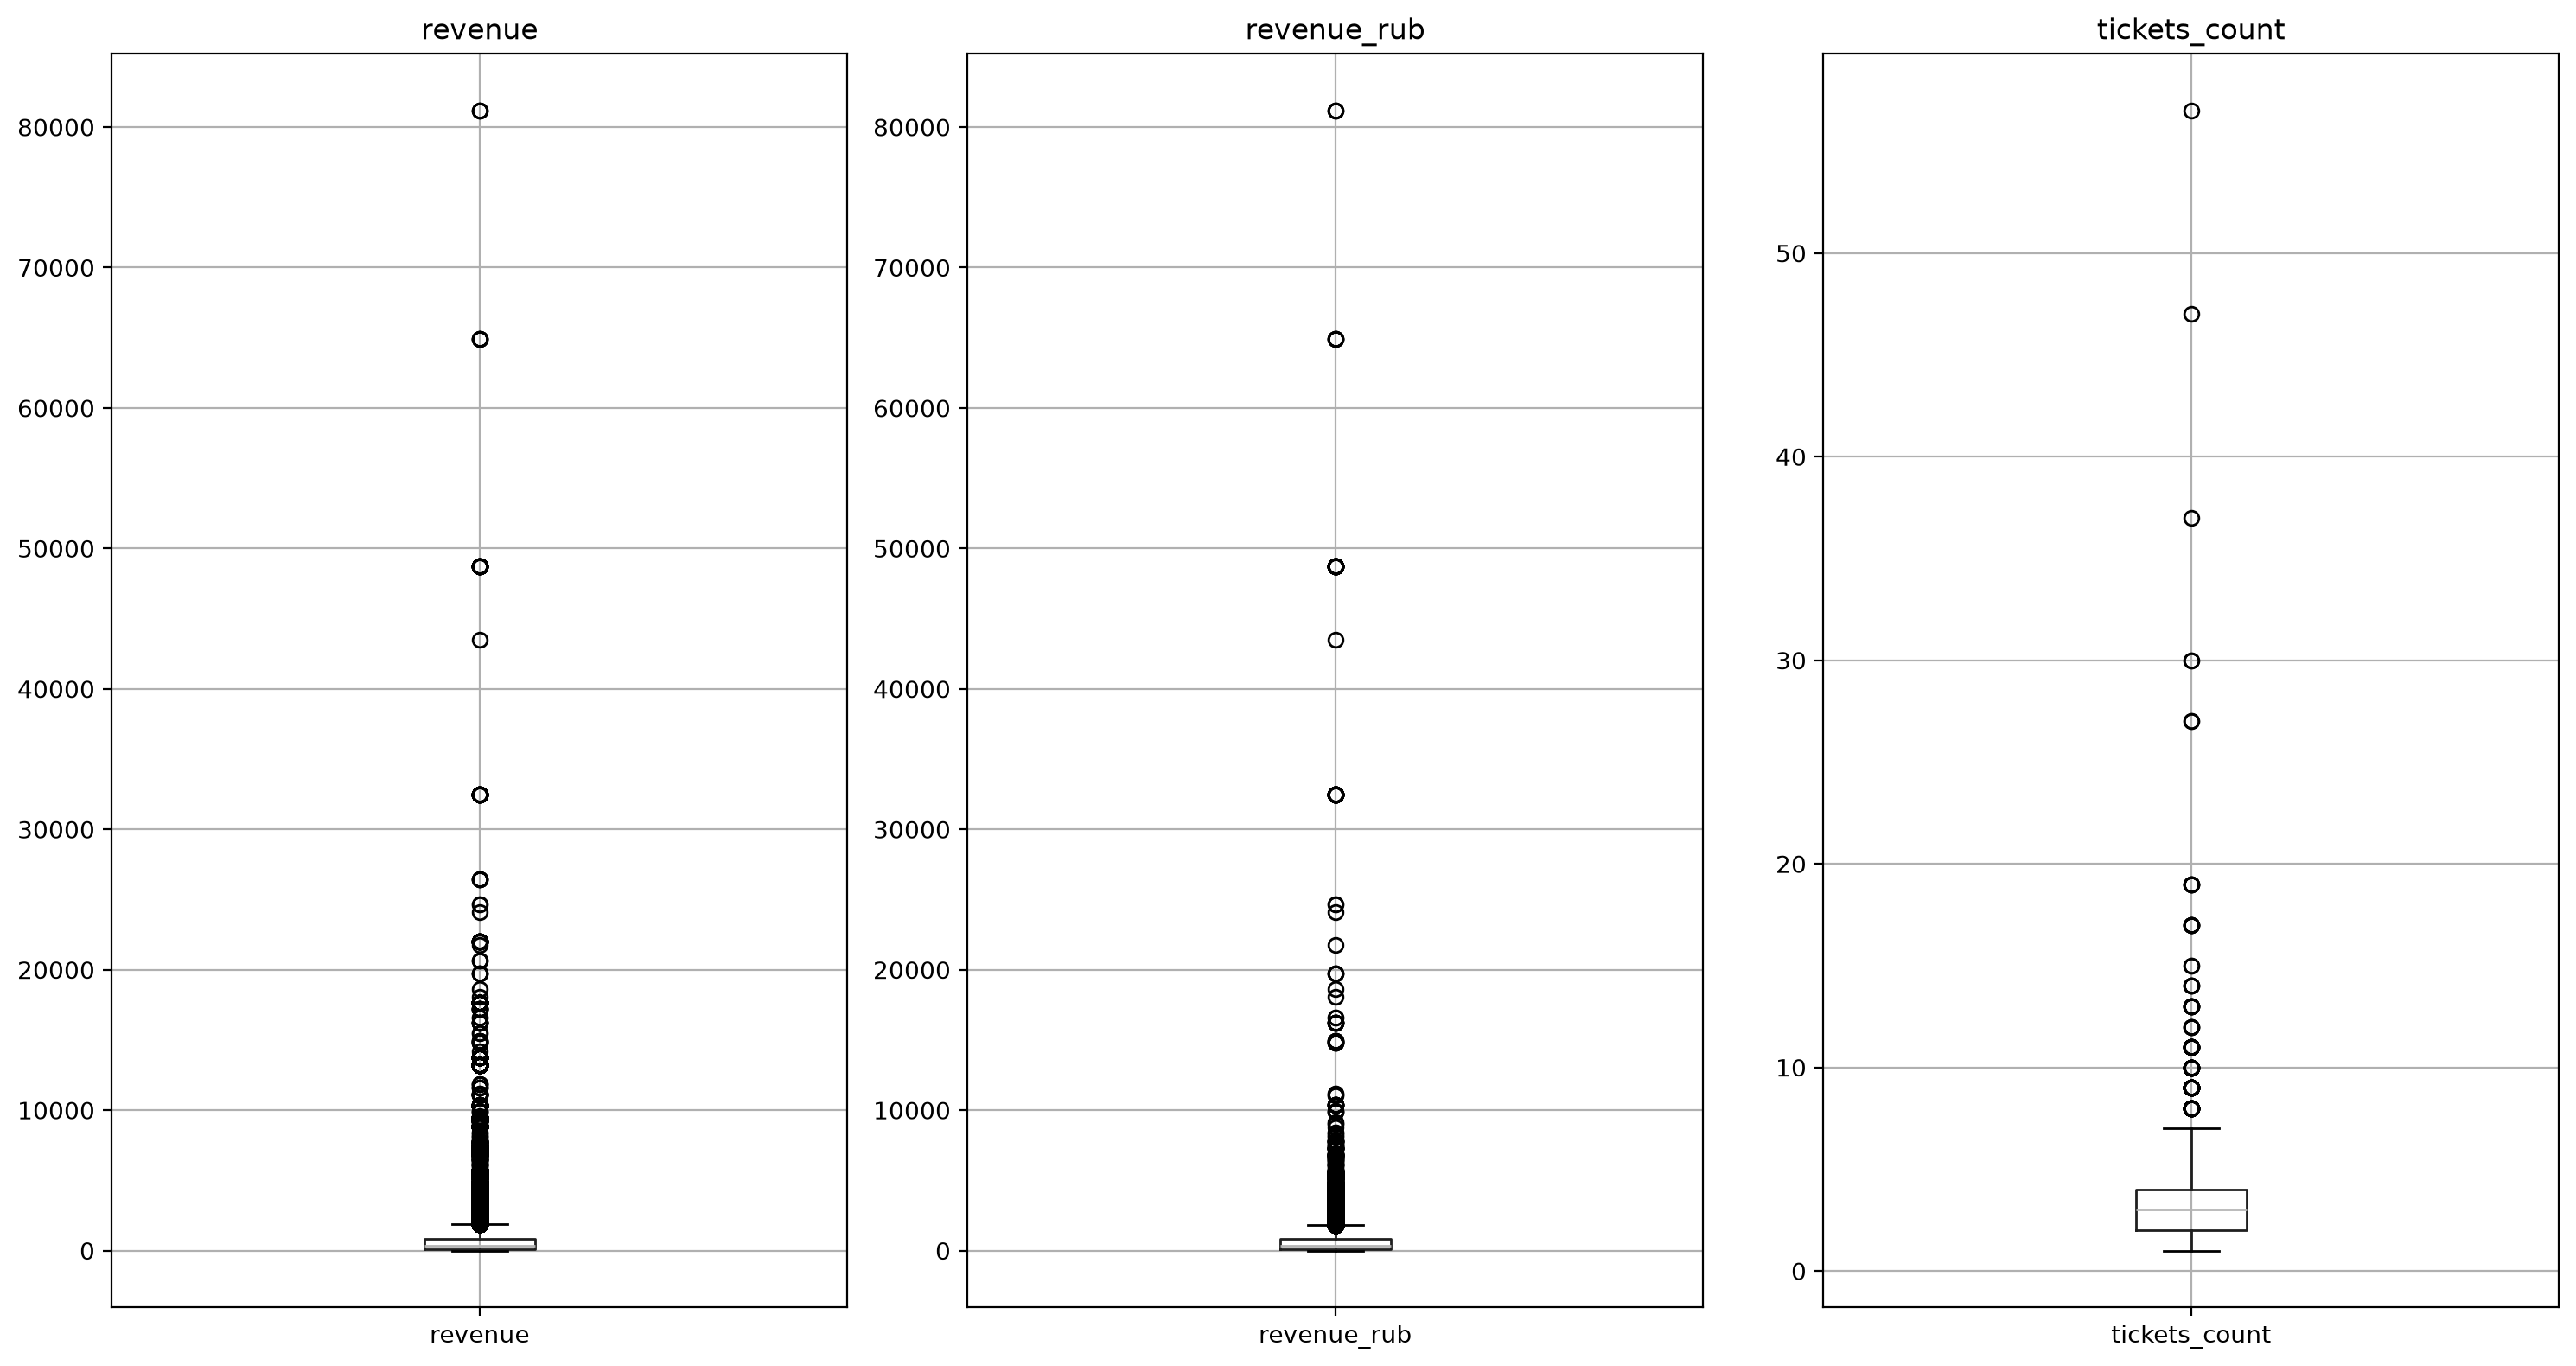

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 8), dpi=200)

columns = ['revenue', 'revenue_rub', 'tickets_count']

for ax, column in zip(axes, columns):
    tickets_df.boxplot(column=column, ax=ax)
    ax.set_title(column)

plt.tight_layout()
plt.show()

 - Посмотрим верхние выбросы в revenue_rub. 

In [33]:
threshold = tickets_df['revenue_rub'].quantile(0.99)

df_99 = tickets_df[tickets_df['revenue_rub'] > threshold]

display(df_99.groupby('event_type_main')['revenue_rub'].agg(['count', 'mean', 'median', 'min', 'max']))

,count,mean,median,min,max
event_type_main,,,,,
выставки,1,3656.870000,3656.87,3656.87,3656.87
другое,261,2983.159923,2666.80,2664.39,6414.34
концерты,1809,4669.399094,3179.37,2629.08,81174.54
спорт,19,9149.150526,7456.77,2898.20,18641.92
стендап,121,6031.811074,4278.32,2635.11,24680.88
театр,593,3666.852293,3218.96,2633.21,8161.31
ёлки,21,3163.872381,2939.82,2628.63,4362.15


In [34]:
outlier_count = df_99.shape[0]
outlier_share = round(outlier_count / tickets_df.shape[0] * 100, 2)

print(f'Количество заказов выше 99-го перцентиля: {outlier_count}')
print(f'Доля заказов выше 99-го перцентиля: {outlier_share}%')

rows_before = tickets_df.shape[0]

tickets_df = tickets_df[tickets_df['revenue_rub'] <= threshold]

print(f'Строк до фильтрации: {rows_before}')
print(f'Строк после фильтрации: {tickets_df.shape[0]}')
print(f'Удалено строк: {rows_before - tickets_df.shape[0]}')

Количество заказов выше 99-го перцентиля: 2825
Доля заказов выше 99-го перцентиля: 0.97%
Строк до фильтрации: 290230
Строк после фильтрации: 287405
Удалено строк: 2825


In [35]:
display(tickets_df['revenue_rub'].describe())

print(f'Проверка на отрицательные значения в "revenue_rub": {tickets_df['revenue_rub'].min() < 0}')

count    287405.000000
mean        518.719256
std         511.951842
min           0.000000
25%         112.600000
50%         344.830000
75%         788.900000
max        2628.421739
Name: revenue_rub, dtype: float64

Проверка на отрицательные значения в "revenue_rub": False


#### Вывод
Анализ распределений количественных признаков выявил наличие выраженных верхних выбросов в показателях revenue, revenue_rub и tickets_count. Боксплоты подтвердили правостороннюю асимметрию распределений: основная масса заказов сосредоточена в области небольших значений, тогда как небольшая доля наблюдений имеет существенно более высокие значения.
Дополнительная проверка заказов выше 99-го перцентиля по признаку revenue_rub показала, что такие записи соответствуют реальным дорогостоящим заказам и не являются ошибками данных. Однако они составляют 0,97% выборки и способны заметно влиять на статистические показатели и визуализацию.
Для дальнейшего анализа были исключены заказы с revenue_rub, превышающим 99-й перцентиль распределения. После фильтрации в датасете осталось 287405 наблюдения.

---

## 3. Исследовательский анализ данных

В этом разделе проведём исследовательский анализ подготовленных данных. Изучим динамику ключевых бизнес-показателей, структуру выручки, распределение заказов по типам мероприятий, устройствам, возрастным ограничениям, регионам, городам и площадкам.

### 3.1. Динамика количества заказов по месяцам

In [36]:
group_orders = (
    tickets_df
    .groupby('month', as_index=False)
    .agg(
        orders_count=('order_id', 'count')
    )
)

display(group_orders)

,month,orders_count
0,6,33802
1,7,40407
2,8,44561
3,9,69330
4,10,99305


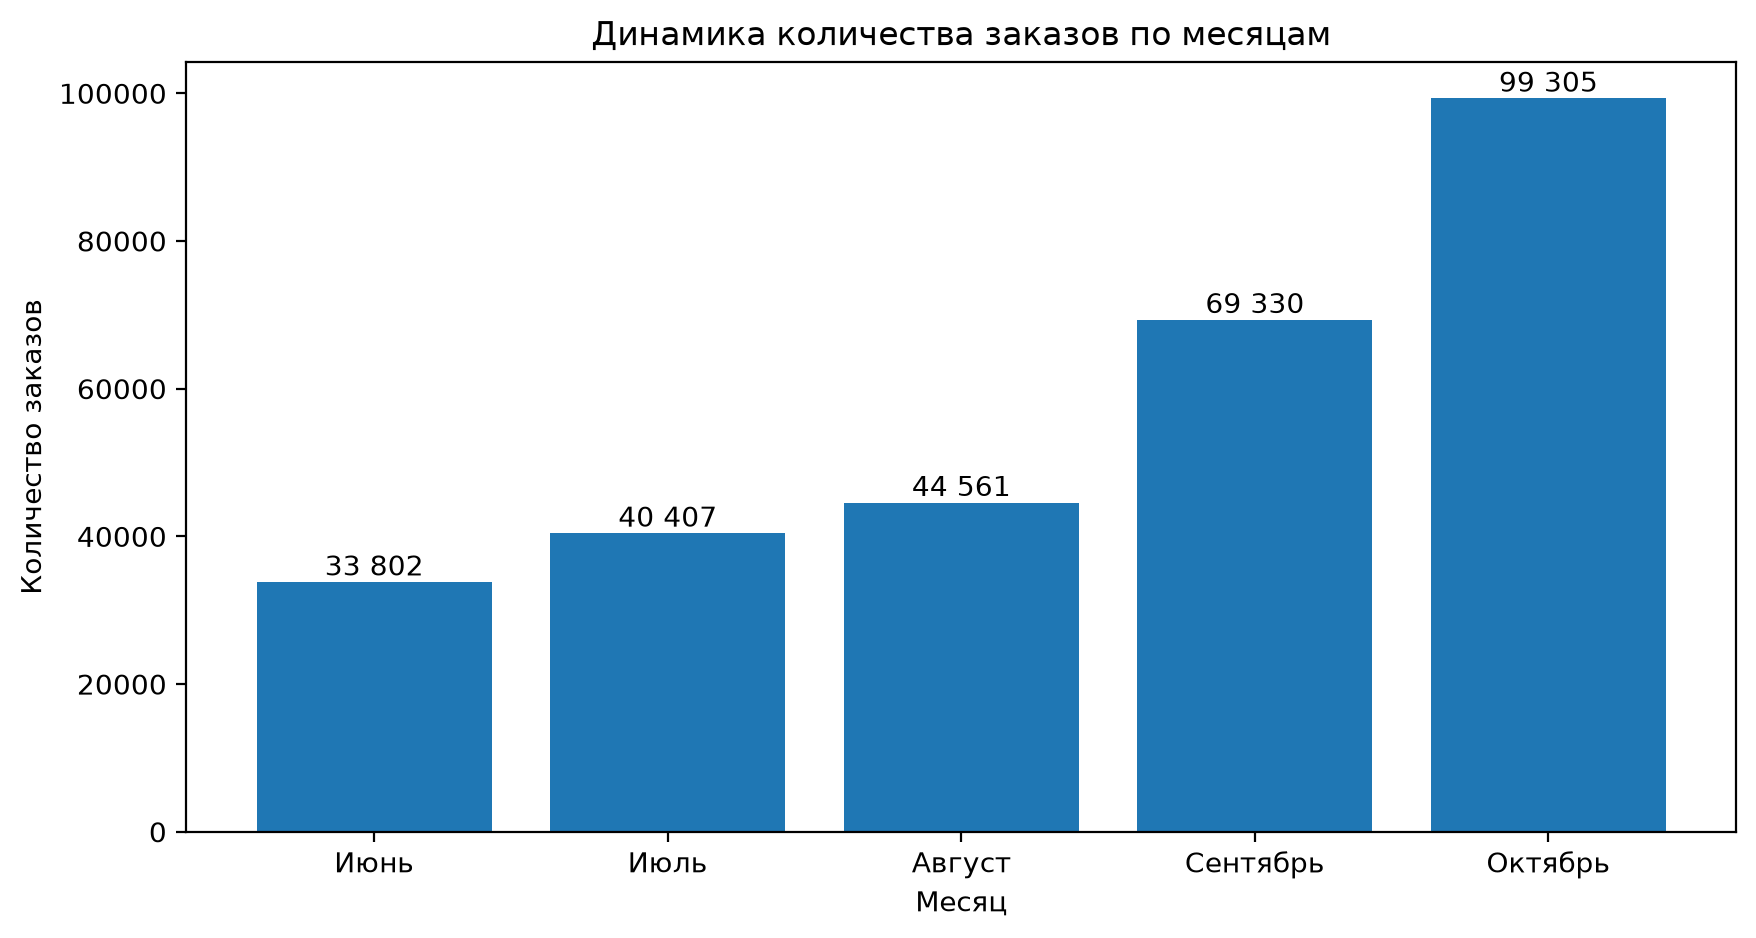

In [37]:
plt.figure(figsize=(10, 5), dpi=200)

bars = plt.bar(group_orders['month'], group_orders['orders_count'])

plt.title('Динамика количества заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')

plt.xticks(
    ticks=[6, 7, 8, 9, 10],
    labels=['Июнь', 'Июль', 'Август', 'Сентябрь', 'Октябрь']
)

# Добавляем подписи над столбцами
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}'.replace(',', ' '),
        ha='center',
        va='bottom'
    )


#### Вывод
Анализ количества заказов по месяцам показал выраженный рост спроса от лета к осени. 
Летом количество заказов увеличивалось постепенно: с 33 802 в июне до 44 561 в августе. 
Осенью рост стал заметно сильнее: в сентябре было оформлено 69 330 заказа, а в октябре — 99 305 заказов.

Таким образом, осенний период характеризуется резким увеличением количества заказов. 
Это подтверждает наличие сезонного роста спроса на мероприятия в сентябре–октябре.

### 3.2. Сравнение структуры заказов летом и осенью

 - Оценим изменения структуры заказов между летним и осенним сезонами по типам мероприятий, устройствам и возрастным ограничениям.

In [38]:
def make_share_table(df, column): 
    # Считаем количество заказов по каждой категории внутри сезона
    group_df = (
        df
        .groupby(['season', column])
        .agg(
            orders_count=('order_id', 'count')
        ).reset_index()
    )
    # Считаем общее количество заказов в каждом сезоне
    group_df['total_season_orders'] = (
            group_df
            .groupby('season')['orders_count']
            .transform('sum')
    )

    # Считаем долю заказов каждой категории внутри сезона
    group_df['share_amount'] = group_df['orders_count'] / group_df['total_season_orders'] * 100

    # Преобразуем таблицу: переносим сезоны в отдельные столбцы
    share_table = (
        group_df
        .pivot_table(
            index=column,
            columns='season',
            values='share_amount', 
        )
        .reset_index()
        .round(2)
    )

    # Считаем изменение доли в процентных пунктах
    share_table['change_pp'] = round(share_table['осень'] - share_table['лето'], 2)

    # Убираем имя столбцов после pivot_table
    share_table.columns.name = None

    return share_table.sort_values(by='change_pp')

In [39]:
event_type_share = make_share_table(tickets_df, 'event_type_main')
device_share = make_share_table(tickets_df, 'device_type_canonical')
age_limit_share = make_share_table(tickets_df, 'age_limit')

display(event_type_share)
display(device_share)
display(age_limit_share)

,event_type_main,лето,осень,change_pp
1,другое,27.12,19.61,-7.51
2,концерты,42.57,37.30,-5.27
4,стендап,5.34,4.11,-1.23
0,выставки,2.03,1.42,-0.61
6,ёлки,0.23,1.01,0.78
5,театр,20.18,25.36,5.18
3,спорт,2.53,11.19,8.66


,device_type_canonical,лето,осень,change_pp
1,mobile,80.67,79.63,-1.04
0,desktop,19.33,20.37,1.04


,age_limit,лето,осень,change_pp
4,18,15.01,10.42,-4.59
3,16,28.43,26.22,-2.21
1,6,18.32,17.69,-0.63
2,12,20.31,22.11,1.80
0,0,17.92,23.55,5.63


In [40]:
def plot_share_change(ax, df, category_col, title, ylabel):

    plot_df = df.sort_values('change_pp')

    colors = plot_df['change_pp'].apply(
        lambda x: 'tab:green' if x > 0 else 'tab:red'
    )

    bars = ax.barh(
        plot_df[category_col],
        plot_df['change_pp'],
        color=colors
    )

    ax.set_title(title)
    ax.set_xlabel('Изменение доли, п.п.')
    ax.set_ylabel(ylabel)

    ax.axvline(
        x=0,
        color='black',
        linestyle='--',
        linewidth=0.3
    )

    ax.set_xlim(
        plot_df['change_pp'].min() - 1,
        plot_df['change_pp'].max() + 1
    )

    for bar in bars:

        value = bar.get_width()

        if value > 0:
            x = value + 0.1
            ha = 'left'
            label = f'+{value:.2f}'
        else:
            x = value - 0.1
            ha = 'right'
            label = f'{value:.2f}'

        ax.text(
            x,
            bar.get_y() + bar.get_height() / 2,
            label,
            va='center',
            ha=ha
        )

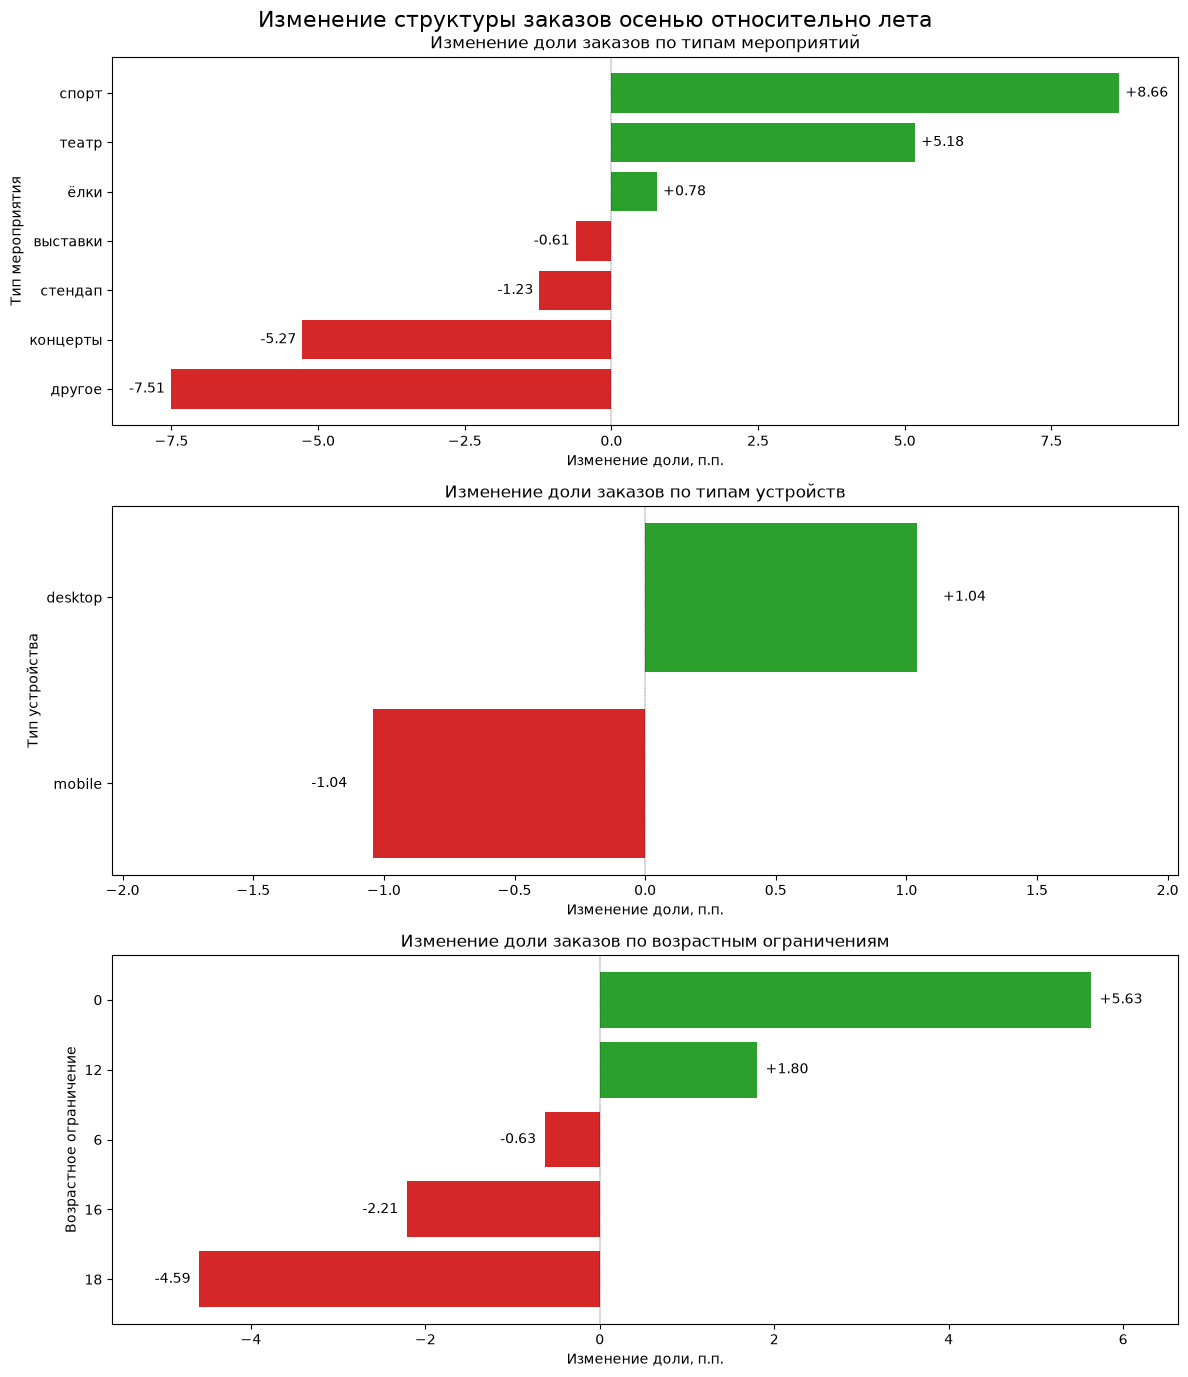

In [41]:
age_limit_share['age_limit'] = age_limit_share['age_limit'].astype(str)

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 14), 
    dpi=100
)

fig.suptitle(
    'Изменение структуры заказов осенью относительно лета',
    fontsize=16
)

plot_share_change(
    axes[0],
    event_type_share,
    'event_type_main',
    'Изменение доли заказов по типам мероприятий',
    'Тип мероприятия'
)

plot_share_change(
    axes[1],
    device_share,
    'device_type_canonical',
    'Изменение доли заказов по типам устройств',
    'Тип устройства'
)

plot_share_change(
    axes[2],
    age_limit_share,
    'age_limit',
    'Изменение доли заказов по возрастным ограничениям',
    'Возрастное ограничение'
)

plt.tight_layout()

plt.show()

- Так же в рамках этой задачи измерим средней стоимости одного билета осенью относительно лета

In [42]:
ticket_price_by_type = (
    tickets_df
    .groupby(['season', 'event_type_main'])
    .agg(
        avg_ticket_price=('ticket_price_rub', 'mean')
    )
)

ticket_price_pivot = (
    ticket_price_by_type
    .pivot_table(
        index='event_type_main',
        columns='season',
        values='avg_ticket_price'
    )
    .reset_index()
)

ticket_price_pivot['change_abs'] = (
    ticket_price_pivot['осень'] - ticket_price_pivot['лето']
)

ticket_price_pivot['change_pct'] = (
    (ticket_price_pivot['осень'] / ticket_price_pivot['лето'] - 1) * 100
)

ticket_price_pivot[['лето', 'осень', 'change_abs', 'change_pct']] = (
    ticket_price_pivot[['лето', 'осень', 'change_abs', 'change_pct']]
    .round(2)
)

ticket_price_pivot = ticket_price_pivot.sort_values(
    'change_pct',
    ascending=False
)

display(ticket_price_pivot)

season,event_type_main,лето,осень,change_abs,change_pct
3,спорт,750.89,914.25,163.36,21.76
4,стендап,1904.46,2132.77,228.30,11.99
1,другое,1379.83,1399.05,19.22,1.39
0,выставки,854.60,857.77,3.17,0.37
2,концерты,3340.94,2900.43,-440.52,-13.19
5,театр,2468.58,2102.82,-365.76,-14.82
6,ёлки,2685.74,2223.42,-462.32,-17.21


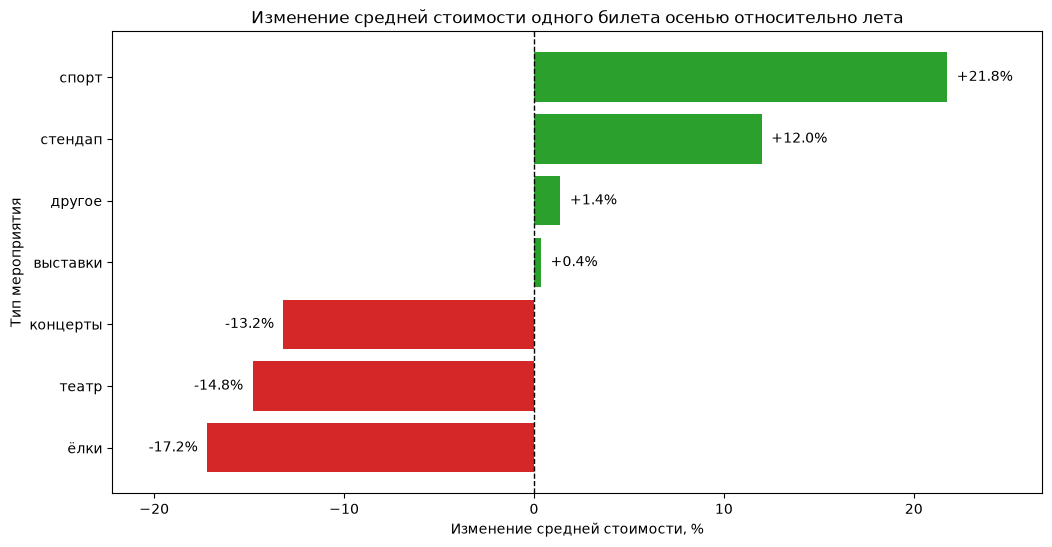

In [43]:
ticket_price_plot = ticket_price_pivot.sort_values('change_pct')

colors = ticket_price_plot['change_pct'].apply(
    lambda x: 'tab:green' if x > 0 else 'tab:red'
)

plt.figure(figsize=(12, 6), dpi=100)

bars = plt.barh(
    ticket_price_plot['event_type_main'],
    ticket_price_plot['change_pct'],
    color=colors
)

plt.title('Изменение средней стоимости одного билета осенью относительно лета')
plt.xlabel('Изменение средней стоимости, %')
plt.ylabel('Тип мероприятия')

plt.axvline(0, color='black', linestyle='--', linewidth=1)

plt.xlim(
    ticket_price_plot['change_pct'].min() - 5,
    ticket_price_plot['change_pct'].max() + 5
)

for bar in bars:
    width = bar.get_width()

    if width > 0:
        x_position = width + 0.5
        ha = 'left'
        label = f'+{width:.1f}%'
    else:
        x_position = width - 0.5
        ha = 'right'
        label = f'{width:.1f}%'

    plt.text(
        x_position,
        bar.get_y() + bar.get_height() / 2,
        label,
        va='center',
        ha=ha
    )

plt.show()

#### Вывод

Осенью структура заказов заметно изменилась. Наибольший рост доли показали спортивные мероприятия (+8.66 п.п.) и театр (+5.18 п.п.), тогда как доля концертов (-5.27 п.п.) и категории «другое» (-7.51 п.п.) сократилась. Среди устройств наблюдается небольшое увеличение доли заказов с desktop (+1.04 п.п.) при соответствующем снижении доли mobile. По возрастным ограничениям выросла доля мероприятий без ограничений (0+) (+5.63 п.п.) и категории 12+ (+1.80 п.п.), тогда как доля мероприятий 18+ (-4.59 п.п.) и 16+ (-2.21 п.п.) снизилась. При этом средняя стоимость билета увеличилась для спорта (+21.76%) и стендапа (+11.99%), тогда как наиболее заметное снижение произошло у концертов (-13.19%), ёлок (-17.21%) и театра (-14.82%).

## 3.3. Осенняя активность пользователей

 - Для анализа пользовательской активности были отобраны данные только за осенний период — сентябрь и октябрь 2024 года. 
Дополнительно были созданы признаки даты, дня недели и типа дня: будний или выходной.

In [44]:
autumn_df = tickets_df[tickets_df['season'] == 'осень'].copy() 

autumn_df['weekday'] = autumn_df['created_dt_msk'].dt.weekday

autumn_df['weekday_name'] = autumn_df['weekday'].map({
    0: 'понедельник',
    1: 'вторник',
    2: 'среда',
    3: 'четверг',
    4: 'пятница',
    5: 'суббота',
    6: 'воскресенье'
})

autumn_df['day_type'] = autumn_df['weekday'].apply(
    lambda weekday: 'выходной' if weekday > 4 else 'будний'
)

autumn_df[['created_dt_msk', 'weekday_name', 'weekday', 'day_type']].head()

,created_dt_msk,weekday_name,weekday,day_type
2,2024-10-06,воскресенье,6,выходной
4,2024-10-04,пятница,4,будний
5,2024-10-23,среда,2,будний
7,2024-09-29,воскресенье,6,выходной
8,2024-10-15,вторник,1,будний


### 3.3.1. Динамика пользовательской активности по дням

Для оценки ежедневной активности пользователей была подготовлена сводная таблица по дням. 
В ней рассчитаны общее количество заказов, число активных пользователей, среднее количество заказов на одного пользователя и средняя стоимость одного билета.

In [45]:
daily_activity = (
    autumn_df
    .groupby(
        [
            'created_dt_msk', 
            'weekday_name', 
            'weekday',
            'day_type'
        ],
        as_index=False
    )
    .agg
        (
            orders_count=('order_id', 'count'), 
            dau=('user_id', 'nunique'), 
            avg_ticket_price=('ticket_price_rub','mean')
        )
)

daily_activity['orders_per_user'] = daily_activity['orders_count'] / daily_activity['dau']

daily_activity['orders_per_user'] = daily_activity['orders_per_user'].round(2) 

daily_activity['avg_ticket_price'] = daily_activity['avg_ticket_price'].round(2) 

display(daily_activity.head())
print(daily_activity.shape[0])

,created_dt_msk,weekday_name,weekday,day_type,orders_count,dau,avg_ticket_price,orders_per_user
0,2024-09-01,воскресенье,6,выходной,1331,565,2297.90,2.36
1,2024-09-02,понедельник,0,будний,1376,573,2198.63,2.40
2,2024-09-03,вторник,1,будний,5095,777,1302.26,6.56
3,2024-09-04,среда,2,будний,1761,684,2174.84,2.57
4,2024-09-05,четверг,3,будний,1942,739,2197.24,2.63


61


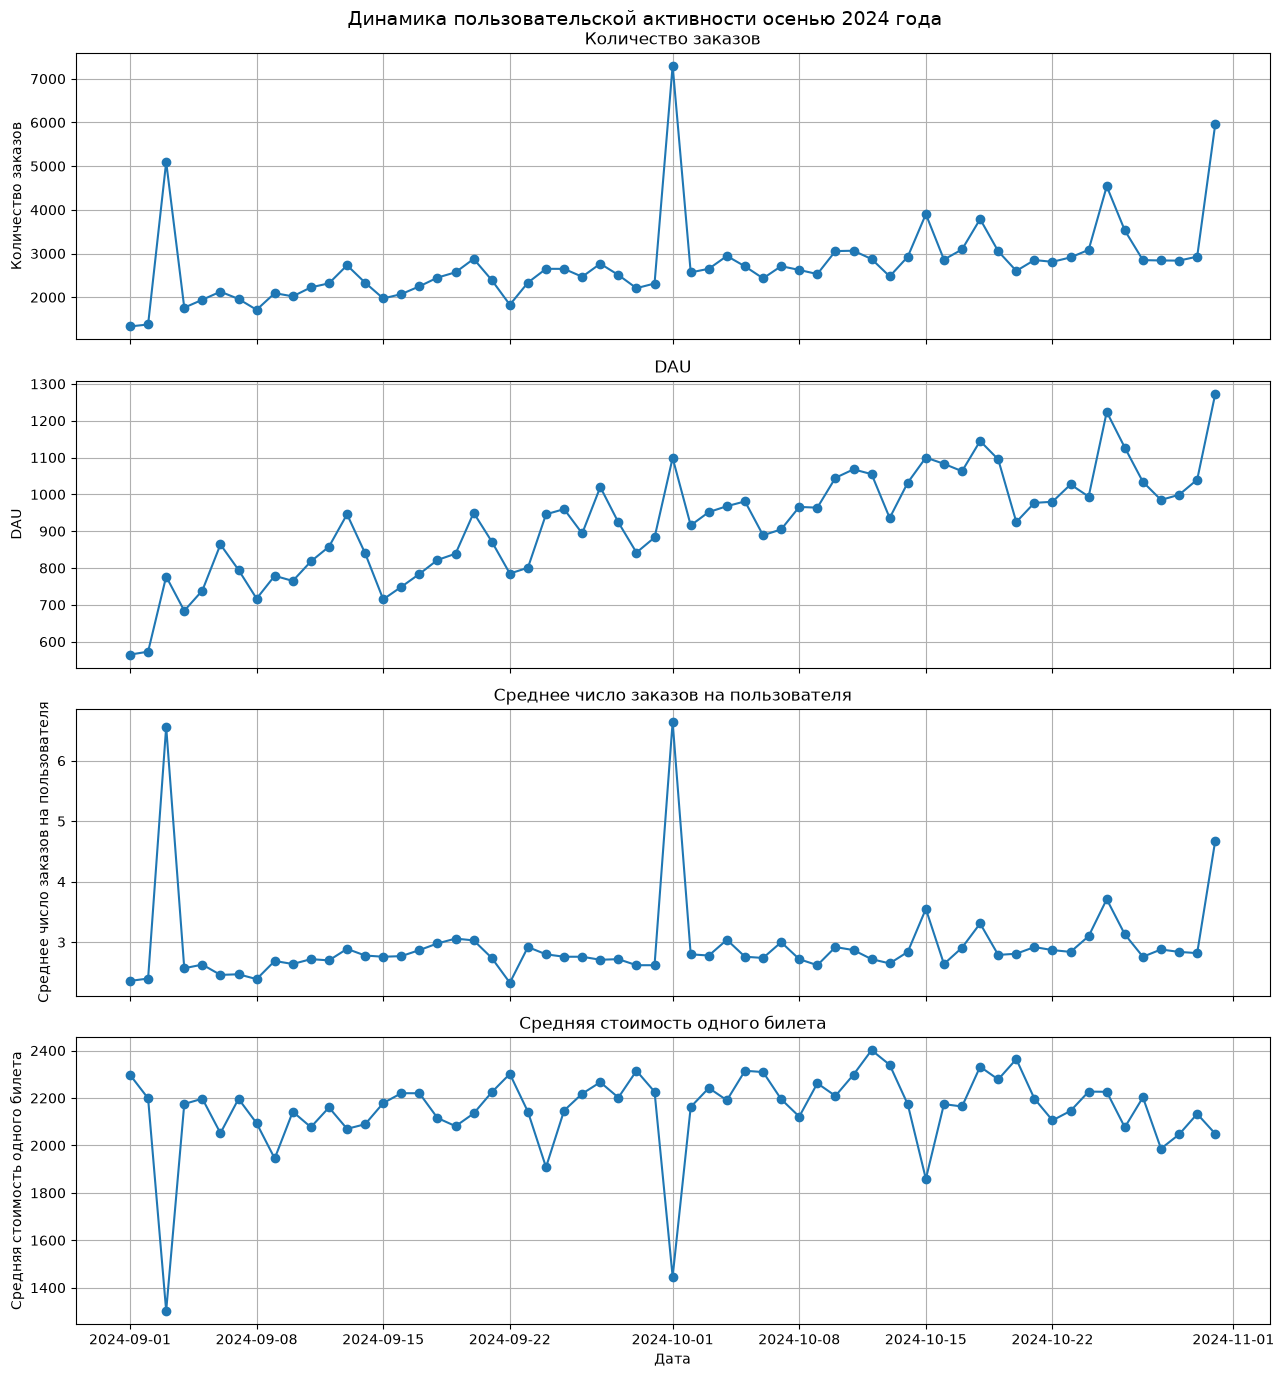

In [46]:
fig, axes = plt.subplots(4, 1, figsize=(13, 14), sharex=True, dpi=100)

metrics = [
    ('orders_count', 'Количество заказов'),
    ('dau', 'DAU'),
    ('orders_per_user', 'Среднее число заказов на пользователя'),
    ('avg_ticket_price', 'Средняя стоимость одного билета')
]

for ax, (metric, title) in zip(axes, metrics):
    ax.plot(daily_activity['created_dt_msk'], daily_activity[metric], marker='o')
    ax.set_title(title)
    ax.set_ylabel(title)
    ax.grid(True)

axes[-1].set_xlabel('Дата')

fig.suptitle('Динамика пользовательской активности осенью 2024 года', fontsize=14)

plt.tight_layout()
plt.show()

### 3.3.2. Анализ недельной цикличности

- Для изучения недельной цикличности сравним пользовательскую активность в будние и выходные дни. 
Сравнение проведём по четырём метрикам: количеству заказов, DAU, среднему числу заказов на пользователя и средней стоимости одного билета.

In [47]:
day_type_activity =(
        daily_activity
        .groupby('day_type', as_index=False)
        .agg(
            avg_orders_count=('orders_count','mean'),
            avg_dua=('dau','mean'),
            avg_orders_per_user=('orders_per_user','mean'),
            avg_ticket_price=('avg_ticket_price','mean'),
            days_count=('created_dt_msk','count')
        )
)
day_type_activity[
    [
        'avg_orders_count', 
        'avg_dua', 
        'avg_orders_per_user', 
        'avg_ticket_price'
    ]
] = day_type_activity[
    [
        'avg_orders_count', 
        'avg_dua', 
        'avg_orders_per_user', 
        'avg_ticket_price'
    ]
].round(2)

day_type_activity.head()


,day_type,avg_orders_count,avg_dua,avg_orders_per_user,avg_ticket_price,days_count
0,будний,2906.20,937.64,3.06,2112.49,44
1,выходной,2397.76,888.06,2.68,2246.31,17


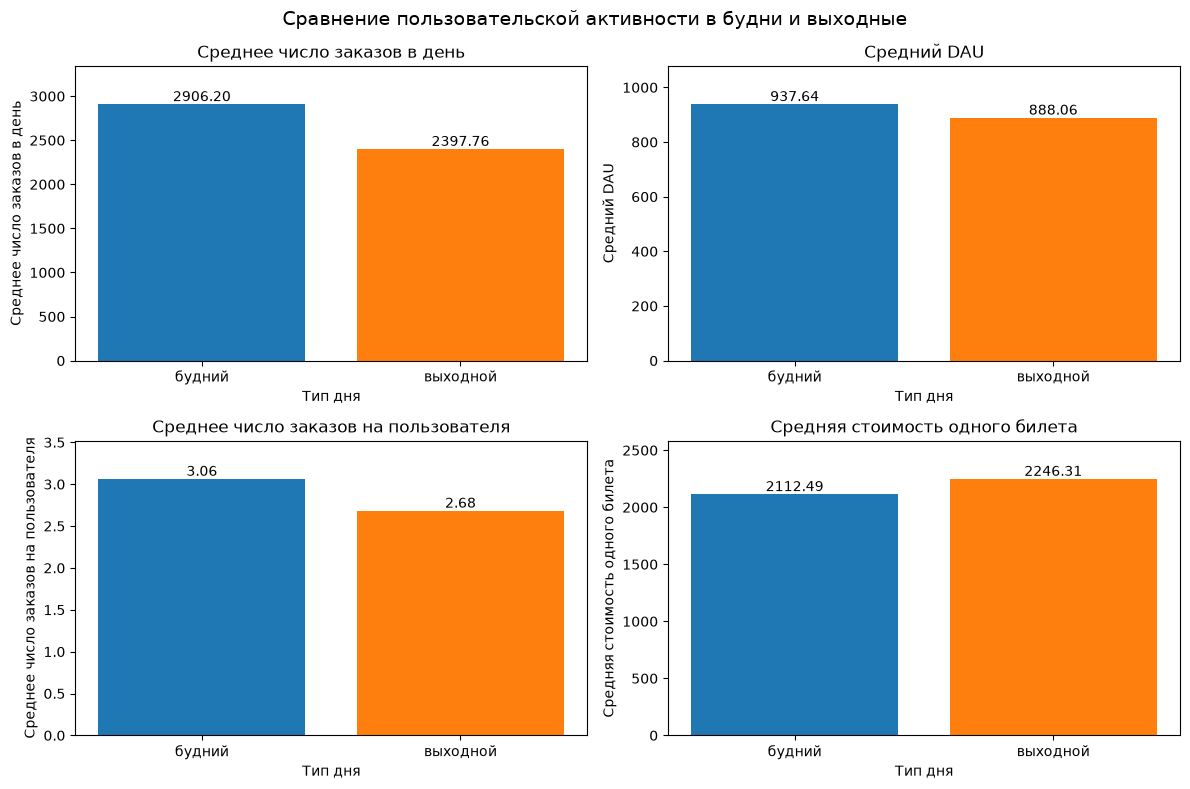

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=100)

metrics = [
    ('avg_orders_count', 'Среднее число заказов в день'),
    ('avg_dua', 'Средний DAU'),
    ('avg_orders_per_user', 'Среднее число заказов на пользователя'),
    ('avg_ticket_price', 'Средняя стоимость одного билета')
]

colors = ['tab:blue', 'tab:orange']

for ax, (metric, title) in zip(axes.flatten(), metrics):
    bars = ax.bar(
        day_type_activity['day_type'],
        day_type_activity[metric],
        color=colors
    )
    
    ax.set_title(title)
    ax.set_xlabel('Тип дня')
    ax.set_ylabel(title)
    
    # Добавляем запас сверху для подписей
    ax.set_ylim(0, day_type_activity[metric].max() * 1.15)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.2f}',
            ha='center',
            va='bottom'
        )

fig.suptitle(
    'Сравнение пользовательской активности в будни и выходные',
    fontsize=14
)

plt.tight_layout()
plt.show()

#### Вывод

Осенью пользовательская активность постепенно увеличивалась: к концу октября выросло количество активных пользователей и заказов. При этом в отдельные даты наблюдались выраженные пики активности, сопровождавшиеся увеличением среднего числа заказов на пользователя. Сравнение будних и выходных дней показало, что в будни пользователи совершали больше заказов: в среднем **2 906.20 заказа** против **2 397.76** в выходные. Также в будни были выше средний DAU (**937.64** против **888.06**) и среднее количество заказов на одного пользователя (**3.06** против **2.68**). В выходные средняя стоимость билета была выше: **2 246.31 руб.** против **2 112.49 руб.** в будни, что может быть связано с различиями в структуре приобретаемых мероприятий. 

## 3.4. Популярные события и партнёры

### 3.4.1. Анализ распределения мероприятий и заказов по регионам
- Для оценки регионального распределения рассчитаем по каждому региону количество уникальных мероприятий и количество заказов. 
Дополнительно посчитаем долю мероприятий и долю заказов, чтобы понять, какие регионы дают основной вклад в предложение событий и пользовательский спрос.

In [49]:
region_activity =(tickets_df
    .groupby('region_name', as_index=False)
    .agg(
        events_count=('event_id', 'nunique'),
        orders_count=('order_id', 'count')
    )
)

region_activity['event_share'] = (region_activity['events_count'] / region_activity['events_count'].sum() * 100).round(2)

region_activity['orders_share'] = (region_activity['orders_count'] / region_activity['orders_count'].sum() * 100).round(2)

display(region_activity.sort_values(by='events_count', ascending=False).head(10))

,region_name,events_count,orders_count,event_share,orders_share
23,Каменевский регион,5940,89758,26.64,31.23
60,Североярская область,3798,43744,17.03,15.22
77,Широковская область,1225,16102,5.49,5.60
57,Светополянский округ,1068,7488,4.79,2.61
52,Речиновская область,701,6267,3.14,2.18
74,Травяная область,683,5036,3.06,1.75
11,Горицветская область,551,5154,2.47,1.79
61,Серебринская область,541,5591,2.43,1.95
78,Яблоневская область,534,6122,2.39,2.13
69,Тепляковская область,528,4386,2.37,1.53


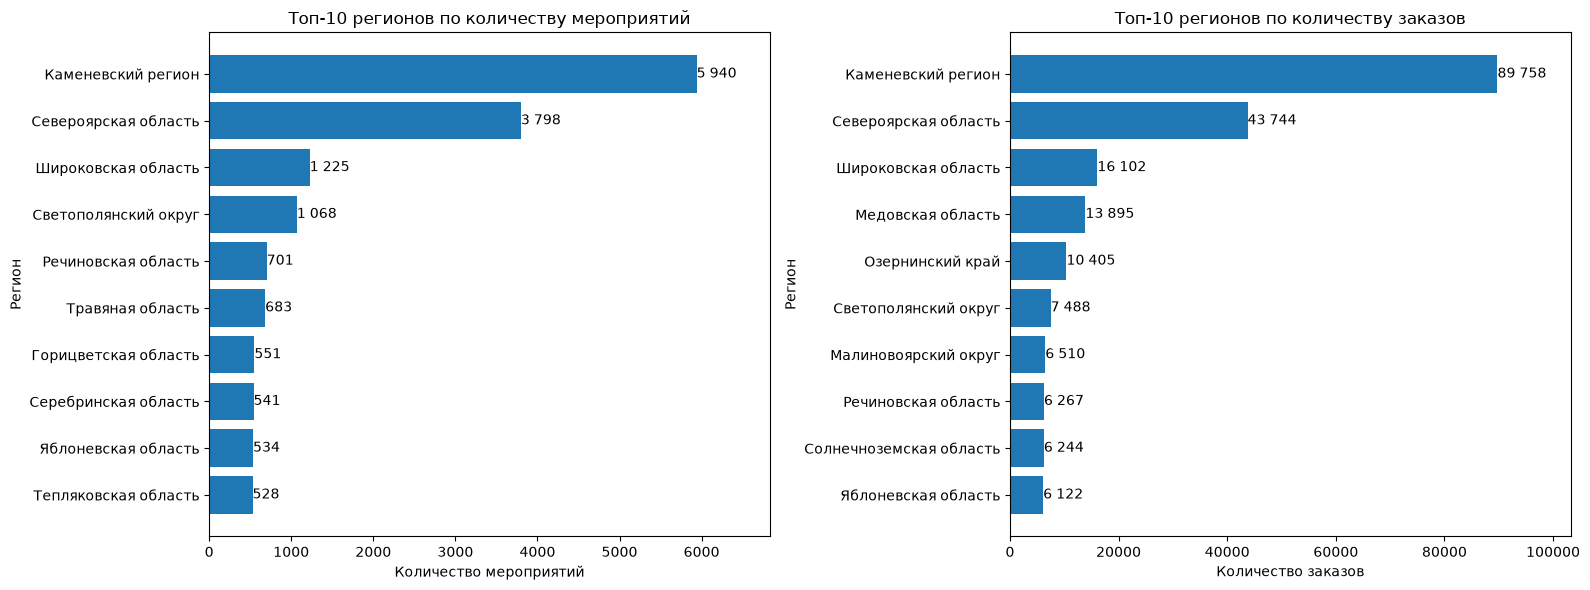

In [50]:
top_regions_by_events = region_activity.sort_values(
    'events_count',
    ascending=False
).head(10)

top_regions_by_orders = region_activity.sort_values(
    'orders_count',
    ascending=False
).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=100)

bars_1 = axes[0].barh(
    top_regions_by_events['region_name'],
    top_regions_by_events['events_count']
)

axes[0].set_title('Топ-10 регионов по количеству мероприятий')
axes[0].set_xlabel('Количество мероприятий')
axes[0].set_ylabel('Регион')
axes[0].invert_yaxis()

axes[0].set_xlim(
    0,
    top_regions_by_events['events_count'].max() * 1.15
)

for bar in bars_1:
    width = bar.get_width()
    axes[0].text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f'{width:,.0f}'.replace(',', ' '),
        va='center',
        ha='left'
    )

bars_2 = axes[1].barh(
    top_regions_by_orders['region_name'],
    top_regions_by_orders['orders_count']
)

axes[1].set_title('Топ-10 регионов по количеству заказов')
axes[1].set_xlabel('Количество заказов')
axes[1].set_ylabel('Регион')
axes[1].invert_yaxis()

axes[1].set_xlim(
    0,
    top_regions_by_orders['orders_count'].max() * 1.15
)

for bar in bars_2:
    width = bar.get_width()
    axes[1].text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f'{width:,.0f}'.replace(',', ' '),
        va='center',
        ha='left'
    )

plt.tight_layout()
plt.show()

### 3.4.2. Анализ билетных партнёров
- Для анализа билетных партнёров рассчитаем по каждому партнёру количество уникальных мероприятий, количество обработанных заказов и суммарную выручку. 
Дополнительно посчитаем долю заказов и долю выручки, чтобы определить партнёров с наибольшим вкладом в продажи.

In [51]:
partner_activity =(tickets_df
    .groupby('service_name', as_index=False)
    .agg(
            orders_count=('order_id', 'count'), 
            events_count=('event_id','nunique'),
            revenue_sum=('revenue_rub','sum')
        )   
)


partner_activity['orders_share'] = (
    partner_activity['orders_count'] / partner_activity['orders_count'].sum() * 100
)

partner_activity['revenue_share'] = (
    partner_activity['revenue_sum'] / partner_activity['revenue_sum'].sum() * 100
)

partner_activity[
    ['revenue_sum', 'orders_share', 'revenue_share']
] = partner_activity[
    ['revenue_sum', 'orders_share', 'revenue_share']
].round(2)

partner_activity = partner_activity.sort_values(
    'revenue_sum',
    ascending=False
)

display(partner_activity.head())

,service_name,orders_count,events_count,revenue_sum,orders_share,revenue_share
3,Билеты без проблем,62852,4211,24863185.61,21.87,16.68
24,Мой билет,34142,1300,21063898.99,11.88,14.13
25,Облачко,26410,2335,18609295.34,9.19,12.48
21,Лови билет!,40791,4862,16730252.46,14.19,11.22
8,Весь в билетах,16438,856,16566881.11,5.72,11.11


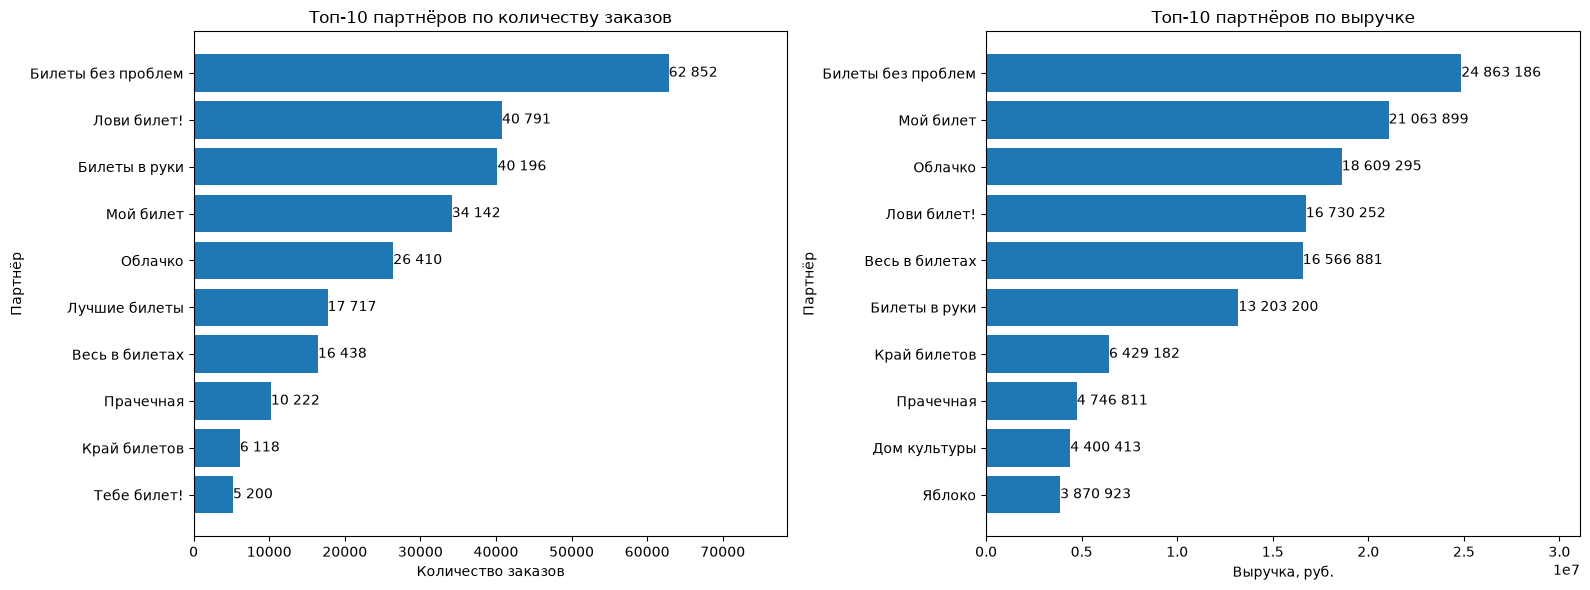

In [52]:
top_partners_by_orders = partner_activity.sort_values(
    'orders_count',
    ascending=False
).head(10)

top_partners_by_revenue = partner_activity.sort_values(
    'revenue_sum',
    ascending=False
).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=100)

bars_1 = axes[0].barh(
    top_partners_by_orders['service_name'],
    top_partners_by_orders['orders_count']
)

axes[0].set_title('Топ-10 партнёров по количеству заказов')
axes[0].set_xlabel('Количество заказов')
axes[0].set_ylabel('Партнёр')
axes[0].invert_yaxis()

axes[0].set_xlim(
    0,
    top_partners_by_orders['orders_count'].max() * 1.25
)

for bar in bars_1:
    width = bar.get_width()
    axes[0].text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f'{width:,.0f}'.replace(',', ' '),
        va='center',
        ha='left'
    )

bars_2 = axes[1].barh(
    top_partners_by_revenue['service_name'],
    top_partners_by_revenue['revenue_sum']
)

axes[1].set_title('Топ-10 партнёров по выручке')
axes[1].set_xlabel('Выручка, руб.')
axes[1].set_ylabel('Партнёр')
axes[1].invert_yaxis()

axes[1].set_xlim(
    0,
    top_partners_by_revenue['revenue_sum'].max() * 1.25
)

for bar in bars_2:
    width = bar.get_width()
    axes[1].text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f'{width:,.0f}'.replace(',', ' '),
        va='center',
        ha='left'
    )

plt.tight_layout()
plt.show()

#### Вывод

Региональное распределение заказов оказалось неравномерным. Основная часть мероприятий и пользовательского спроса сосредоточена в нескольких регионах. Лидером является Каменевский регион, который формирует наибольшую долю как мероприятий (**26.64%**), так и заказов (**31.23%**). При этом для отдельных регионов доля заказов превышает долю мероприятий, что может свидетельствовать о более высоком спросе на события в этих регионах.

Анализ билетных партнёров также показал высокую концентрацию продаж. Партнёр **«Билеты без проблем»** занимает первое место по количеству заказов (**63 042 заказа**) и объёму выручки (**24.86 млн руб.**). При этом лидеры по количеству заказов и выручке не полностью совпадают, что указывает на различия в средней выручке с заказа и структуре продаваемых мероприятий.

Таким образом, продажи распределены неравномерно как между регионами, так и между билетными партнёрами. Основной вклад в пользовательский спрос и выручку обеспечивают относительно небольшое число регионов и партнёров, что говорит о высокой концентрации рынка. 

---

## 4. Статистический анализ данных
В этом разделе проверим две гипотезы о различиях в активности пользователей мобильных и стационарных устройств. 
Для проверки гипотез используем только данные за осенний период — сентябрь и октябрь 2024 года.

### 4.1. Проверка независимости групп

Перед проверкой гипотез важно убедиться, что сравниваемые группы можно считать независимыми. Если один и тот же пользователь оформляет заказы и с `mobile`, и с `desktop`, его наблюдения попадают сразу в обе группы и нарушают предпосылку независимости для t-теста.

Поэтому сначала оценим масштаб пересечения пользователей, а затем сформируем выборку только из тех пользователей, которые осенью использовали один тип устройства.

In [53]:
user_device_counts = (
    autumn_df
    .groupby('user_id')['device_type_canonical']
    .nunique()
    .reset_index()
)

both_device_users = user_device_counts.loc[
    user_device_counts['device_type_canonical'] > 1, 
    'user_id'
]

mobile_users = autumn_df.loc[
    autumn_df['device_type_canonical']=='mobile', 
    'user_id'
].nunique()

desktop_users = autumn_df.loc[
    autumn_df['device_type_canonical']=='desktop', 
    'user_id'
].nunique()

all_autumn_users = autumn_df['user_id'].nunique()

print(f'Всего пользователей осенью: {all_autumn_users}')
print(f'Пользователей mobile: {mobile_users}')
print(f'Пользователей desktop: {desktop_users}')
print(f'Пользователей, использовавших оба устройства: {both_device_users.nunique()}')
print(f'Доля пользователей с обоими устройствами: {both_device_users.nunique() / all_autumn_users * 100:.2f}%')

independent_autumn_df = autumn_df[
    ~autumn_df['user_id'].isin(both_device_users)
].copy()

display(independent_autumn_df['device_type_canonical'].value_counts())

Всего пользователей осенью: 15813
Пользователей mobile: 14190
Пользователей desktop: 4873
Пользователей, использовавших оба устройства: 3250
Доля пользователей с обоими устройствами: 20.55%


device_type_canonical
mobile     31272
desktop     3195
Name: count, dtype: int64

#### Вывод

Часть пользователей совершала заказы как с мобильных, так и со стационарных устройств. Такие пользователи создают зависимость между группами mobile и desktop, что нарушает предпосылку независимости для t-теста.

Чтобы сравнение было методологически корректнее, из статистического анализа были исключены пользователи, использовавшие оба типа устройств. Далее гипотезы проверяются только на независимых группах: пользователях, которые осенью совершали заказы только с mobile, и пользователях, которые совершали заказы только с desktop.

### 4.2. Гипотеза 1: среднее количество заказов на пользователя у mobile выше, чем у desktop

Первая гипотеза связана с проверкой различий в среднем количестве заказов на одного пользователя между пользователями мобильных и стационарных устройств.

В качестве метрики используется количество заказов на одного пользователя за осенний период. Для проверки гипотезы используем только независимые группы пользователей и перейдём с уровня заказов на уровень пользователя: рассчитаем количество заказов для каждой пары `user_id` — `device_type_canonical` в датафрейме `independent_autumn_df`.

In [54]:
user_orders_independent = (independent_autumn_df
    .groupby(['user_id', 'device_type_canonical'], as_index=False)
    .agg(orders_count=('order_id', 'count'))
)

user_orders_independent.head()

,user_id,device_type_canonical,orders_count
0,0005ca5e93f2cf4,mobile,1
1,000898990054619,mobile,2
2,000a55a418c128c,mobile,2
3,001e7037d013f0f,mobile,2
4,00245c702bc343e,mobile,2


In [55]:
user_orders_independent_summary = (user_orders_independent
    .groupby('device_type_canonical', as_index=False)
    .agg(
        users_count=('user_id','count'), 
        mean_orders=('orders_count','mean'), 
        median_orders=('orders_count','median'),
        std_orders=('orders_count','std')
    )
    .round(2)
)

user_orders_independent_summary.head()

,device_type_canonical,users_count,mean_orders,median_orders,std_orders
0,desktop,1623,1.97,1.0,3.07
1,mobile,10940,2.86,2.0,4.10


#### Формулировка гипотез

**Нулевая гипотеза (H₀):** среднее количество заказов на пользователя у mobile не выше, чем у desktop.

**Альтернативная гипотеза (H₁):** среднее количество заказов на пользователя у mobile выше, чем у desktop.

Математически:

H₀: μ_mobile ≤ μ_desktop  
H₁: μ_mobile > μ_desktop

#### Выбор статистического теста

После исключения пользователей, использовавших оба типа устройств, группы `mobile` и `desktop` можно считать независимыми.

Для проверки гипотезы используется t-тест Уэлча для двух независимых выборок. Выбор теста обусловлен тем, что сравниваются средние значения двух групп, а размеры групп и дисперсии могут различаться, поэтому используется вариант теста с `equal_var=False`. Так как альтернативная гипотеза предполагает, что среднее значение у mobile выше, тест проводится как односторонний.

In [56]:
alpha = 0.05

mobile_orders = user_orders_independent.loc[
    user_orders_independent['device_type_canonical']=='mobile',
    'orders_count'
]

desktop_orders = user_orders_independent.loc[
    user_orders_independent['device_type_canonical']=='desktop',
    'orders_count'
]

stat_ttest, p_value_ttest = stats.ttest_ind(
    mobile_orders,
    desktop_orders,
    equal_var=False,
    alternative='greater'
)

print(f't-статистика: {stat_ttest:.4f}')
print(f'p-value: {p_value_ttest:.4f}')

if p_value_ttest < alpha:
    print('Нулевая гипотеза отвергается: среднее количество заказов на пользователя у mobile статистически значимо выше, чем у desktop.')
else:
    print('Оснований отвергнуть нулевую гипотезу нет: статистически значимого превышения среднего количества заказов на пользователя у mobile не обнаружено.')

t-статистика: 10.3815
p-value: 0.0000
Нулевая гипотеза отвергается: среднее количество заказов на пользователя у mobile статистически значимо выше, чем у desktop.


#### Вывод по гипотезе 1

После исключения пользователей, использовавших оба типа устройств, среднее количество заказов на пользователя в группе mobile составило **2.86**, а в группе desktop — **1.97**. Медианное значение также оказалось выше у mobile: **2 заказа против 1 заказа** у desktop.

Для проверки гипотезы был применён односторонний t-тест Уэлча для двух независимых выборок. Значение t-статистики составило **10.3819**, а p-value оказалось **меньше 0.0001**, что ниже уровня значимости 0.05.

Следовательно, нулевая гипотеза отвергается. Есть статистические основания считать, что в независимых группах пользователи mobile в среднем совершают больше заказов, чем пользователи desktop. 

### 4.3. Гипотеза 2: среднее время между заказами у mobile выше, чем у desktop

Вторая гипотеза связана с проверкой различий в среднем времени между заказами у пользователей мобильных и стационарных устройств.

В качестве метрики используется `days_since_prev` — количество дней с предыдущей покупки пользователя. Для корректного сравнения снова используем только независимые группы пользователей и оставляем только строки, где значение `days_since_prev` не пропущено, так как для первой покупки пользователя интервал до предыдущего заказа отсутствует.

In [70]:
days_since_prev_independent_df = (
    independent_autumn_df
    .dropna(subset=['days_since_prev'])
    .copy()
)

display(
    days_since_prev_independent_df[
        ['device_type_canonical', 'days_since_prev']
    ].head()
)

,device_type_canonical,days_since_prev
2,mobile,75.0
4,mobile,83.0
5,mobile,19.0
8,mobile,16.0
27,mobile,74.0


In [71]:
user_avg_days = (
    days_since_prev_independent_df
    .groupby(['user_id', 'device_type_canonical'], as_index=False)
    .agg(avg_days_since_prev=('days_since_prev', 'mean'))
)

display(user_avg_days.head())

,user_id,device_type_canonical,avg_days_since_prev
0,0005ca5e93f2cf4,mobile,75.0
1,000898990054619,mobile,51.0
2,000a55a418c128c,mobile,16.0
3,001e7037d013f0f,mobile,43.5
4,00245c702bc343e,mobile,27.5


In [72]:
user_avg_days.groupby('device_type_canonical')['avg_days_since_prev'].describe()

,count,mean,std,min,25%,50%,75%,max
device_type_canonical,,,,,,,,
desktop,894.0,31.440543,36.585441,0.0,0.000000,16.0,53.0,146.0
mobile,7054.0,25.259207,30.224364,0.0,2.879934,14.0,36.0,148.0


In [60]:
user_avg_days.groupby('device_type_canonical')['user_id'].nunique()

device_type_canonical
desktop     894
mobile     7054
Name: user_id, dtype: int64

### Формулировка гипотез

Для проверки различий в среднем времени между заказами сформулируем нулевую и альтернативную гипотезы.

**Нулевая гипотеза (H₀):** среднее время между заказами у пользователей mobile не выше, чем у пользователей desktop.

**Альтернативная гипотеза (H₁):** среднее время между заказами у пользователей mobile выше, чем у пользователей desktop.

Математически:

H₀: μ_mobile ≤ μ_desktop  
H₁: μ_mobile > μ_desktop

### Выбор статистического теста

После исключения пользователей, использовавших оба типа устройств, сравниваются две независимые группы: mobile и desktop.

Для проверки гипотезы используется t-тест Уэлча для двух независимых выборок. Выбор теста обусловлен тем, что сравниваются средние значения двух групп, а размеры выборок и дисперсии могут различаться, поэтому используется вариант теста с `equal_var=False`.

Так как альтернативная гипотеза предполагает, что среднее значение у mobile выше, чем у desktop, тест проводится как односторонний.

In [73]:
mobile_user_days = user_avg_days.loc[
    user_avg_days['device_type_canonical'] == 'mobile',
    'avg_days_since_prev'
]

desktop_user_days = user_avg_days.loc[
    user_avg_days['device_type_canonical'] == 'desktop',
    'avg_days_since_prev'
]

stat_ttest_user, p_value_ttest_user = stats.ttest_ind(
    mobile_user_days,
    desktop_user_days,
    equal_var=False,
    alternative='greater'
)

print(f't-статистика: {stat_ttest_user:.4f}')
print(f'p-value: {p_value_ttest_user:.4f}')

t-статистика: -4.8465
p-value: 1.0000


#### Вывод по гипотезе 2

После исключения пользователей, использовавших оба типа устройств, для каждого пользователя было рассчитано среднее время между последовательными заказами. В группе mobile среднее значение составило 25.26 дня, а в группе desktop — 31.44 дня. Медианное значение также оказалось немного ниже у mobile: 14 дней против 16 дней у desktop. При этом распределение метрики остаётся скошенным вправо, а стандартные отклонения достаточно высоки.

Для проверки гипотезы был применён односторонний t-тест Уэлча для двух независимых выборок. Значение t-статистики составило -4.8465, а p-value — 1.0000, что значительно выше уровня значимости 0.05.

Следовательно, оснований отвергнуть нулевую гипотезу нет. Статистически значимого подтверждения того, что среднее время между заказами у пользователей mobile выше, чем у пользователей desktop, не получено. Более того, по описательной статистике средний интервал между заказами у mobile оказался ниже, чем у desktop.

### 4.4. Вывод по статистическому анализу

В рамках статистического анализа были проверены две гипотезы о различиях в активности пользователей мобильных и стационарных устройств за осенний период. Перед тестированием была проверена независимость групп. Выяснилось, что **3 252 пользователя, или 20.56% осенней аудитории, использовали оба типа устройств**. Эти пользователи были исключены из статистических тестов, чтобы сравнение mobile и desktop не нарушало предпосылку независимости.

Первая гипотеза проверяла, выше ли среднее количество заказов на пользователя у mobile по сравнению с desktop. В независимых группах среднее количество заказов на пользователя составило **2.86 у mobile и 1.97 у desktop**. По результатам одностороннего t-теста Уэлча получены **`t = 10.3819` и `p-value < 0.0001`**, поэтому нулевая гипотеза была отвергнута. Есть статистические основания считать, что пользователи mobile в среднем совершают больше заказов, чем пользователи desktop.

Вторая гипотеза проверяла, выше ли среднее время между заказами у mobile по сравнению с desktop. После исключения смешанных пользователей для каждого пользователя было рассчитано среднее время между последовательными заказами. Среднее значение составило **25.26 дня у mobile и 31.44 дня у desktop**, а медианное значение — **14 и 16 дней** соответственно. По результатам одностороннего t-теста Уэлча получены **`t = -4.8465` и `p-value = 1.0000`**, поэтому оснований отвергнуть нулевую гипотезу нет. Статистически значимого подтверждения того, что среднее время между заказами у пользователей mobile выше, чем у пользователей desktop, не получено. Более того, по описательной статистике средний интервал между заказами у mobile оказался ниже, чем у desktop.

При интерпретации результатов важно учитывать, что в обеих гипотезах распределения метрик остаются вариативными и скошенными, а стандартные отклонения достаточно велики. Это говорит о неоднородности пользовательского поведения. Для второй гипотезы особенно важно, что анализ проводился на уровне пользователя: каждому пользователю соответствовало одно среднее значение времени между заказами, что позволяет корректнее сравнивать независимые группы mobile и desktop.

---

## 5. Общий вывод и рекомендации

### 5.1. Общий вывод

В рамках проекта были проанализированы данные сервиса Яндекс Афиша за период с 1 июня по 31 октября 2024 года: заказы билетов, информация о мероприятиях и курс тенге к рублю. На этапе предобработки данные были объединены в единый датафрейм, проверены пропуски, дубликаты, категориальные и количественные значения, а выручка была переведена в рубли. Дополнительно были проверены значения в столбцах `region_name` и `service_name`, так как они используются далее в анализе регионов и билетных партнёров. Для дальнейшего анализа были созданы признаки `revenue_rub`, `one_ticket_revenue_rub`, `ticket_price_rub`, `month`, `season`, а для осеннего периода также `date`, `weekday`, `weekday_name` и `day_type`. Пропуски в `event_type_main` составили 238 строк, или около 0.08% заказов. Их доля незначительна, поэтому они были исключены только из анализа структуры по типам мероприятий.

Анализ сезонной динамики показал выраженный рост спроса от лета к осени. Количество заказов увеличилось с **33 802 в июне** до **40 407 в июле** и **44 561 в августе**, после чего рост заметно ускорился: в сентябре было оформлено **69 330 заказов**, а в октябре уже **99 305**. Это подтверждает, что осенью спрос стал существенно выше, чем летом, и особенно сильный прирост пришёлся на сентябрь и октябрь.

Структура заказов осенью также изменилась. По типам мероприятий сильнее всего выросли доли спорта (**+8.66 п.п.**) и театра (**+5.18 п.п.**), а также категории ёлок (**+0.78 п.п.**). Доля концертов, несмотря на их важность, снизилась на **5.27 п.п.**, а категории «другое» — на **7.51 п.п.**, что говорит о более быстром росте других сегментов. По устройствам структура почти не изменилась: доля desktop выросла на **1.04 п.п.**, а mobile снизилась на **1.04 п.п.** По возрастным ограничениям осенью усилился спрос на более массовые и семейные мероприятия: доля категории `0+` выросла на **5.63 п.п.**, `12+` — на **1.80 п.п.**, тогда как доли `16+` и `18+` сократились на **2.21 и 4.59 п.п.** соответственно.

Рост объёма заказов осенью не сопровождался единым изменением средней стоимости одного билета по всем категориям. Стоимость билета выросла у спорта (**+21.76%**), стендапа (**+11.99%**), категории «другое» (**+1.39%**) и выставок (**+0.37%**). По остальным направлениям средняя стоимость снизилась: у концертов на **13.19%**, у ёлок на **17.21%**, у театра на **14.82%**. Это означает, что осенний рост был связан прежде всего с увеличением количества заказов, а динамика средней стоимости билета зависела от конкретного сегмента мероприятий.

Анализ осенней активности пользователей показал, что в сентябре и октябре DAU постепенно рос, а количество заказов увеличивалось неравномерно, с заметными пиками 3 сентября, 1 октября и в конце октября. В такие дни росло не только число заказов, но и среднее количество заказов на пользователя. Недельная цикличность выражена достаточно чётко: в будние дни в среднем оформлялось **2 906.20 заказа** при среднем DAU **937.64** и **3.06 заказа на пользователя**, тогда как в выходные — **2 397.76 заказа**, DAU **888.06** и **2.68 заказа на пользователя**. При этом средняя стоимость одного билета в выходные выше: **2 246.31 руб.** против **2 112.49 руб.** в будни.

По регионам данные сильно концентрированы. Каменевский регион является явным лидером: **5 940 уникальных мероприятий, 89 758 заказов, 26.64% всех мероприятий и 31.23% всех заказов**. На втором месте находится Североярская область: **3 798 мероприятий, 43 744 заказа, 17.03% мероприятий и 15.22% заказов**. При этом спрос не всегда пропорционален количеству мероприятий: например, в Медовской области доля заказов выше доли мероприятий, а в Светополянском округе — наоборот.

Среди билетных партнёров лидирует «Билеты без проблем»: **63 042 заказа, 24.86 млн руб. выручки, 21.92% заказов и 16.68% выручки**. Также важный вклад вносят «Мой билет» и «Облачко». Лидеры по заказам и выручке совпадают не полностью, что указывает на различия в средней выручке с заказа между партнёрами.

Статистический анализ на осенних данных был проведён только на независимых группах после исключения пользователей, использовавших оба типа устройств. Для количества заказов на пользователя среднее значение у mobile составило **2.86 против 1.97 у desktop**; по результатам одностороннего t-теста Уэлча получены `t = 10.3819` и `p-value < 0.0001`, поэтому есть статистические основания считать, что пользователи mobile в среднем совершают больше заказов. Для времени между заказами каждому пользователю было сопоставлено одно среднее значение интервала между последовательными заказами. Среднее значение составило **25.26 дня у mobile и 31.44 дня у desktop**, а медианное значение — **14 и 16 дней** соответственно. По результатам одностороннего t-теста Уэлча получены `t = -4.8465` и `p-value = 1.0000`, поэтому статистически значимого подтверждения гипотезы о более длинном интервале между заказами у mobile не получено. Более того, по описательной статистике средний интервал между заказами у mobile оказался ниже, чем у desktop.

### 5.2. Рекомендации

Осенний период, особенно сентябрь и октябрь, стоит рассматривать как ключевой сезон роста спроса. Для продуктовой команды это означает, что именно на эти месяцы имеет смысл усиливать маркетинговую активность, расширять ассортимент и заранее готовить инфраструктуру под рост числа заказов.

С точки зрения ассортимента стоит уделить больше внимания спортивным и театральным мероприятиям, так как именно они сильнее всего увеличили долю заказов осенью. Отдельно имеет смысл развивать семейные категории, прежде всего `0+` и `12+`, поскольку осенью спрос заметно сместился в сторону более массовых и семейных событий.

Будни и выходные можно использовать по-разному. Будние дни подходят для кампаний, ориентированных на объём заказов и вовлечение пользователей, так как именно в эти дни выше и число заказов, и DAU, и количество заказов на пользователя. Выходные, наоборот, выглядят более подходящими для продвижения мероприятий с более высокой средней стоимостью билета.

Регионально стоит сохранять фокус на Каменевском регионе и Североярской области как на ключевых источниках спроса, но при этом отдельно изучить регионы, где доля заказов выше доли мероприятий, например Медовскую область. Такие территории могут указывать на точки роста, где спрос уже высок относительно текущего предложения.

Среди партнёров стоит отдельно проанализировать не только лидеров по количеству заказов, но и партнёров с высокой выручкой при меньшем объёме продаж, таких как «Мой билет» и «Облачко». Это поможет понять, где выше средняя ценность заказа и какие практики партнёров можно масштабировать.

Для mobile-аудитории целесообразно сохранять отдельный фокус: в независимых группах пользователи mobile в среднем совершают больше заказов, чем пользователи desktop. При этом статистически значимого подтверждения более длинного среднего интервала между заказами у mobile не получено. Поэтому для этой аудитории имеет смысл концентрироваться на росте объёма заказов и удобстве повторной покупки, не делая предположение о более редком возвращении mobile-пользователей.